In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm
import random
import os
import json
import numpy as np

import george
from functools import partial
import scipy.optimize as op
from astropy.table import Table, vstack
from gaussian_process import *

df = pd.read_csv('gp/gp_objects.csv')
display(df)
obj = sorted(df.obj_id.unique())
len(obj)

,mjd,flux_ztfg,flux_ztfi,flux_ztfr,flux_error_ztfg,flux_error_ztfi,flux_error_ztfr,type,obj_id,mjd_0,...,mag_error_ztfg,mag_ztfr,abs_mag_ztfr,mag_error_ztfr,mag_ztfi,abs_mag_ztfi,mag_error_ztfi,t,rise,fade
0,57983.231000,385.374906,440.341788,404.940209,29.250027,17.182907,24.797305,Kilonova,AT2017gfo,57983.231000,...,0.082408,17.381523,-15.832157,0.066487,17.290525,-15.923154,0.042367,0.000000,n,y
1,57983.239778,382.559484,438.232033,402.502588,28.789575,16.890215,24.361032,Kilonova,AT2017gfo,57983.231000,...,0.081707,17.388078,-15.825601,0.065713,17.295740,-15.917940,0.041846,0.008778,n,y
2,57983.248556,379.738177,436.119876,400.065220,28.332873,16.606597,23.927709,Kilonova,AT2017gfo,57983.231000,...,0.081009,17.394673,-15.819007,0.064937,17.300985,-15.912694,0.041343,0.017556,n,y
3,57983.257333,376.910979,434.005567,397.628148,27.879986,16.332054,23.497397,Kilonova,AT2017gfo,57983.231000,...,0.080312,17.401307,-15.812372,0.064160,17.306262,-15.907418,0.040857,0.026333,n,y
4,57983.266111,374.077886,431.889351,395.191413,27.430981,16.066587,23.070161,Kilonova,AT2017gfo,57983.231000,...,0.079617,17.407981,-15.805698,0.063382,17.311569,-15.902111,0.040390,0.035111,n,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76996,61251.981035,46.827461,71.513942,52.138438,4.065787,11.213241,4.392118,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094269,19.607105,-23.957055,0.091462,19.264023,-24.300137,0.170241,1.738686,n,y
76997,61251.982783,46.805967,71.402238,52.036069,4.063701,11.257768,4.477385,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094264,19.609239,-23.954921,0.093421,19.265720,-24.298439,0.171185,1.740433,n,y
76998,61251.984530,46.784158,71.290549,51.934233,4.064583,11.303560,4.563905,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094328,19.611366,-23.952794,0.095413,19.267420,-24.296740,0.172150,1.742181,n,y
76999,61251.986278,46.762033,71.178879,51.832925,4.068474,11.350597,4.651602,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094463,19.613486,-23.950674,0.097436,19.269122,-24.295038,0.173138,1.743928,n,y


78

In [2]:
color_dict = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'yellow'}
def plot_gp(obj_model, number_col=4, show_title=True, show_legend=True):
    color_dict = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'yellow'}
    f, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlabel('Time (mjd)')
    ax.set_ylabel('Flux') 
    if show_title:
        obj_id = obj_model['obj_id'].iloc[0]
        ax.set_title(f'Light Curve for Object ID: {obj_id} | Type: {obj_model["type"].iloc[0]}')
    if show_legend:
        ax.legend(ncol=number_col)

    # Plotting model data if available
    if obj_model is not None:
        # Iterate over the filters present in the obj_model DataFrame
        for column in obj_model.columns:
            if 'flux' in column and column != 'mjd' and 'abs' not in column:
                filter_name = column.split('_')[1]
                if filter_name in color_dict:
                    if not all(obj_model[column] == -1):
                        ax.plot(obj_model['t'], obj_model[column], label=f'Model {filter_name}', color=color_dict[filter_name])
    
                        # Plot error band if error data is available
                        error_column = f'flux_error_{filter_name}'
                        if error_column in obj_model.columns:
                            model_flux_error = obj_model[error_column]
                            ax.fill_between(obj_model['t'], obj_model[column]-model_flux_error, obj_model[column]+model_flux_error, color=color_dict[filter_name], alpha=0.20)

    return f,ax

In [3]:
def cut_data(df, obj_id, cutoff, plot=True):
    obj_model = df[df['obj_id'] == obj_id]
    if plot:
        f, ax = plot_gp(obj_model)
        ax.axvline(cutoff, color='black', linestyle='--', label='Cutoff')
        plt.show()

    obj_model = obj_model[obj_model['t'] < cutoff]
    combined_df = pd.concat([df[df['obj_id'] != obj_id], obj_model])
    return combined_df

In [4]:
obj[1]

'AT2026brq'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


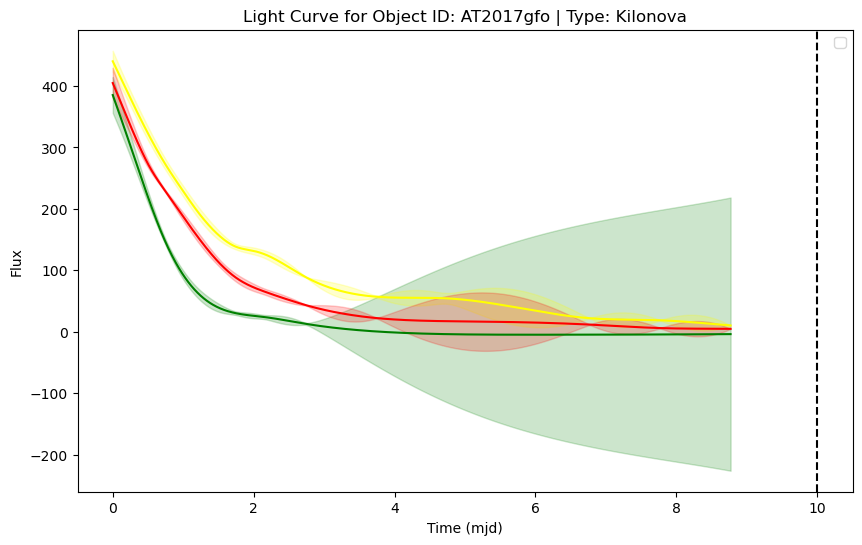

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


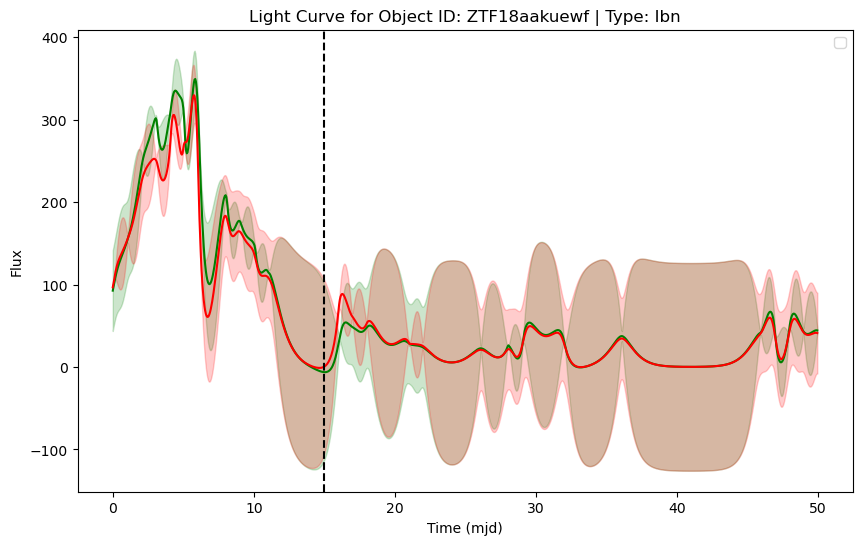

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


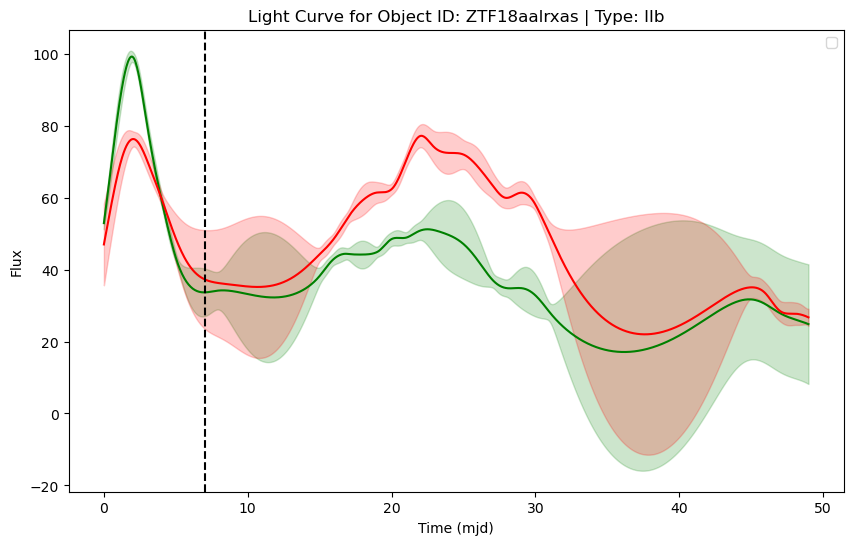

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


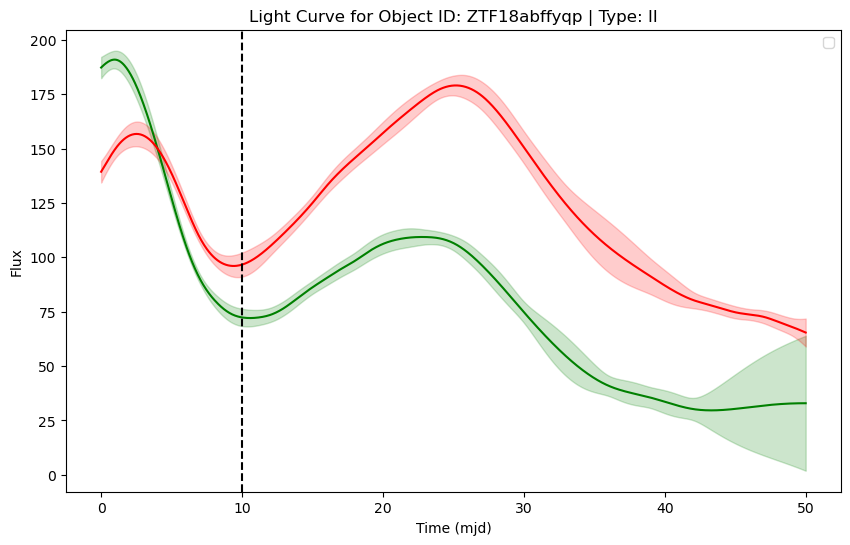

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


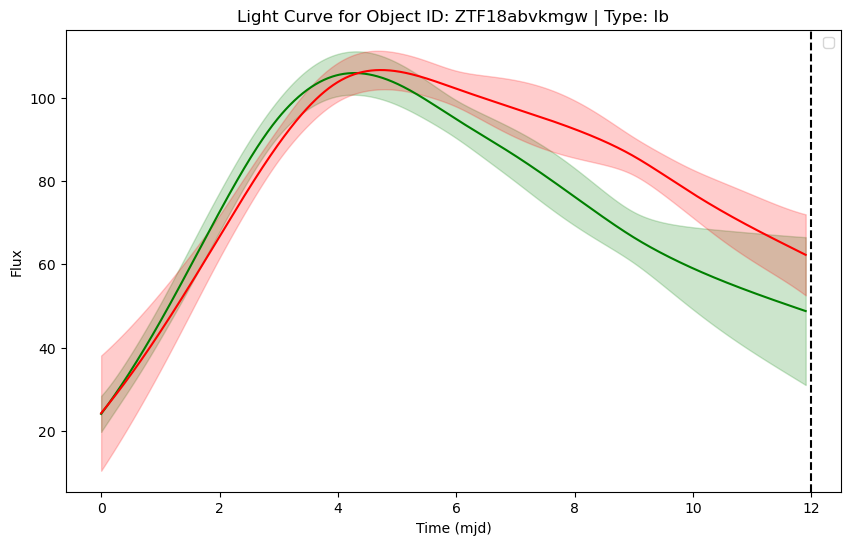

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


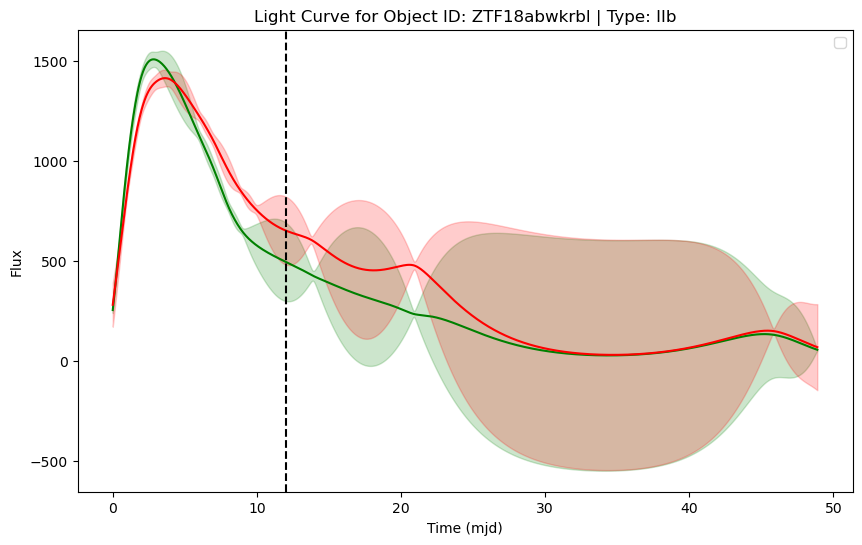

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


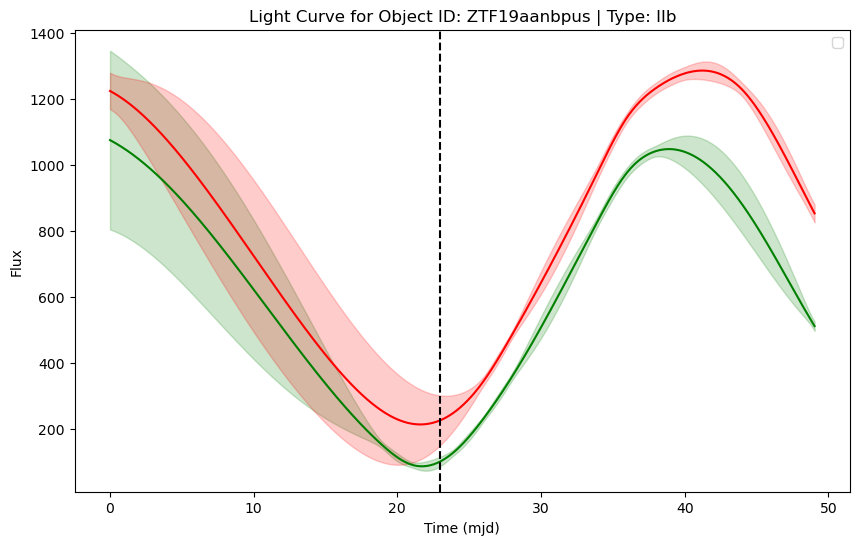

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


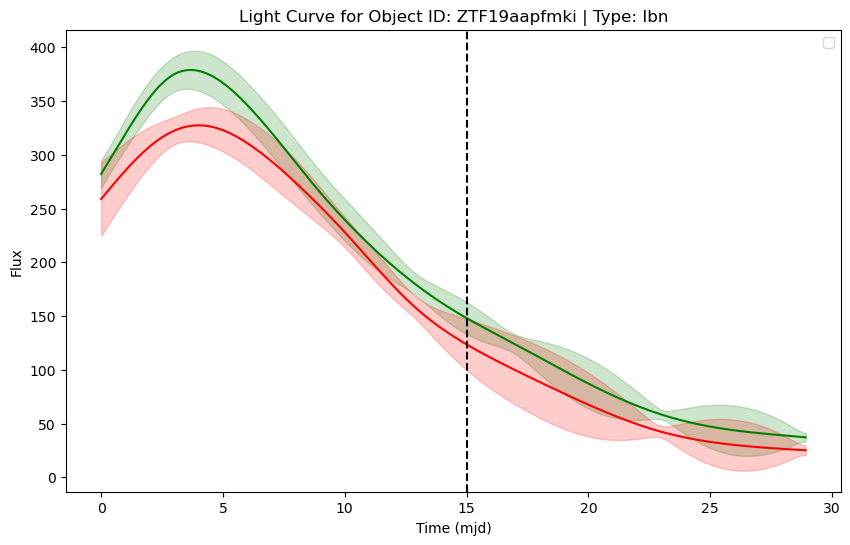

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


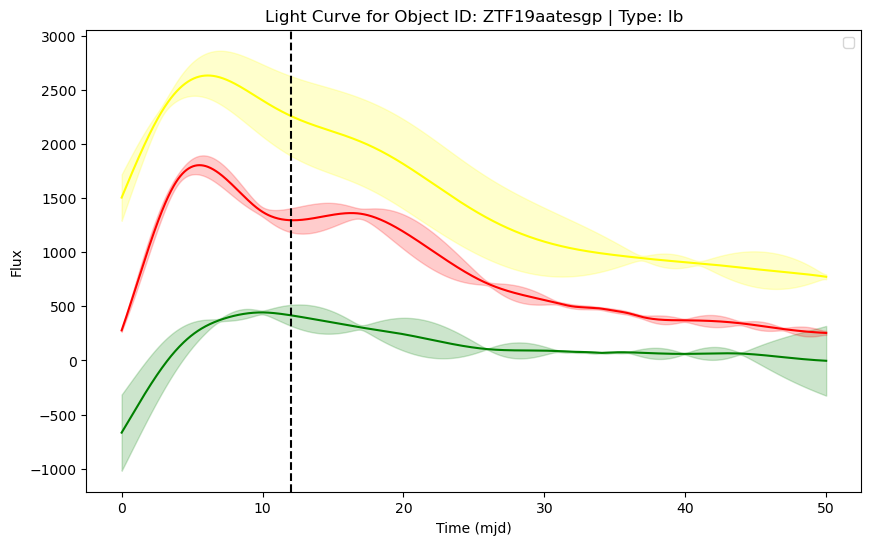

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


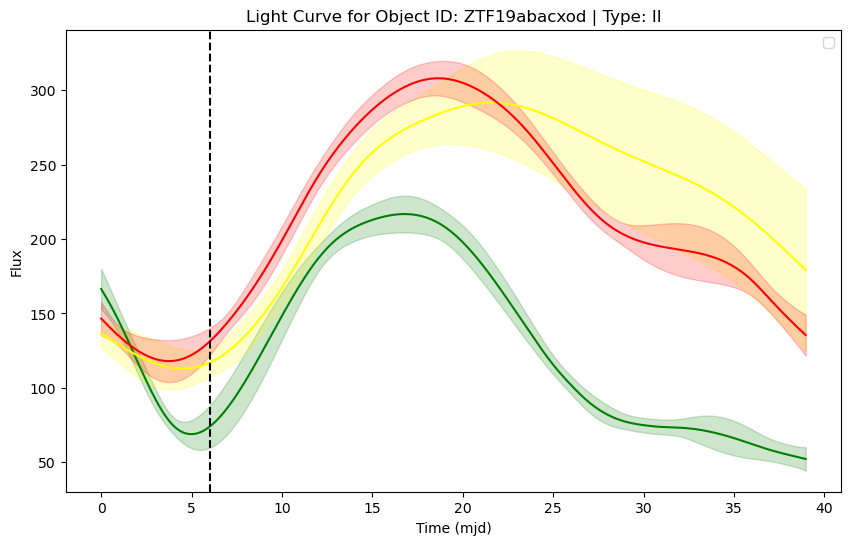

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


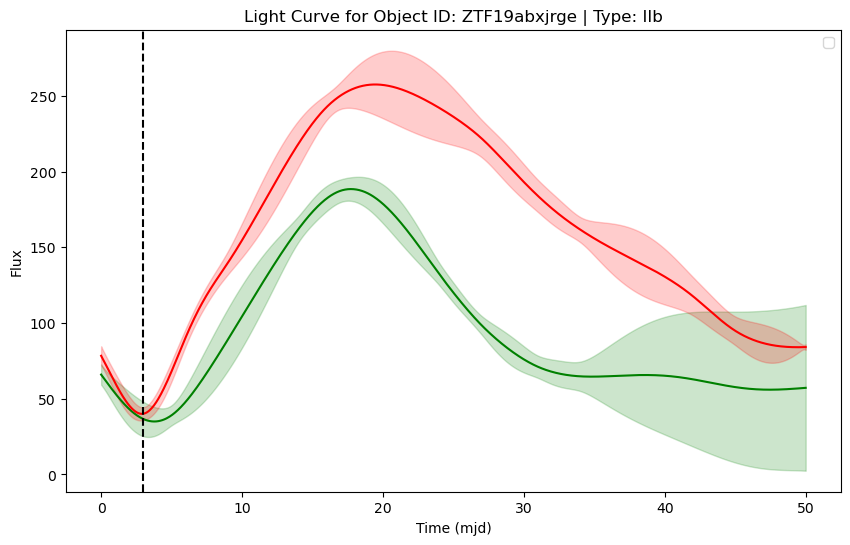

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


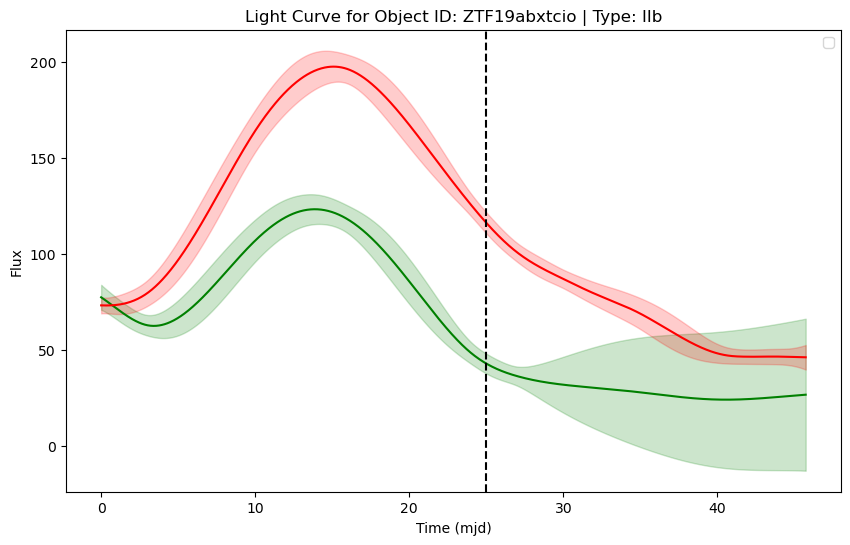

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


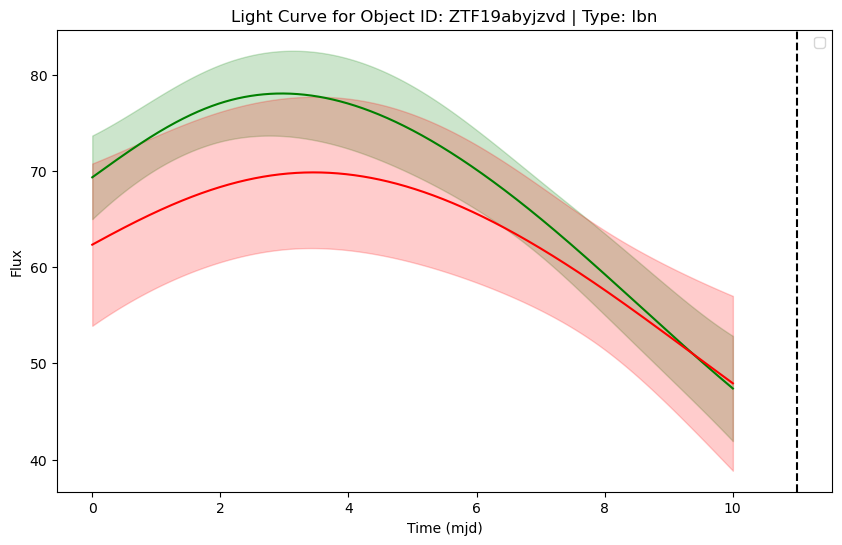

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


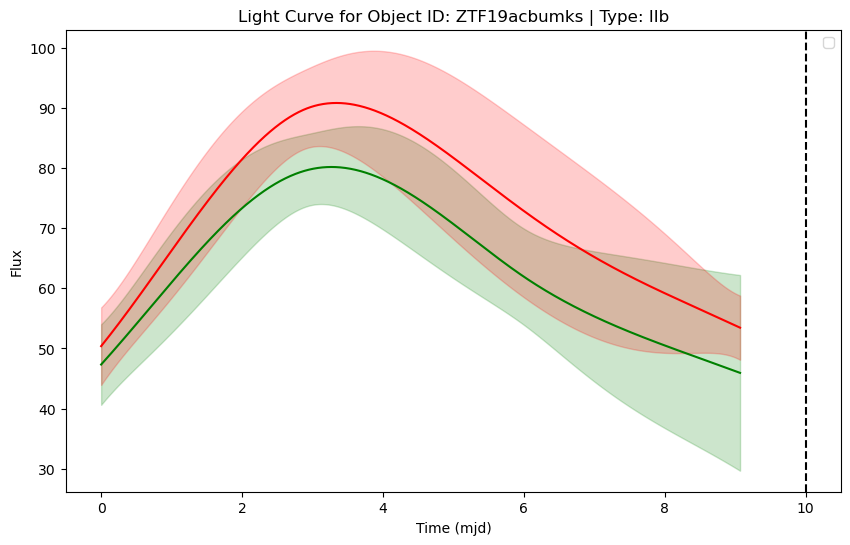

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


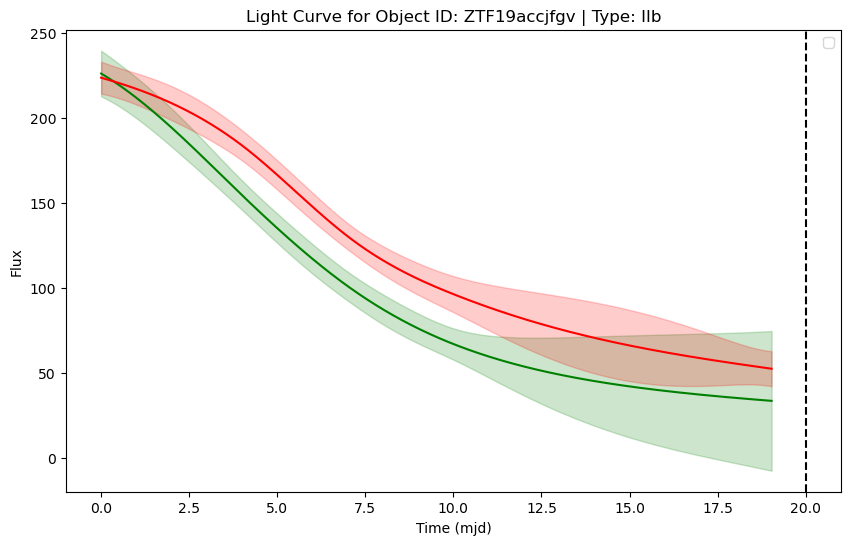

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


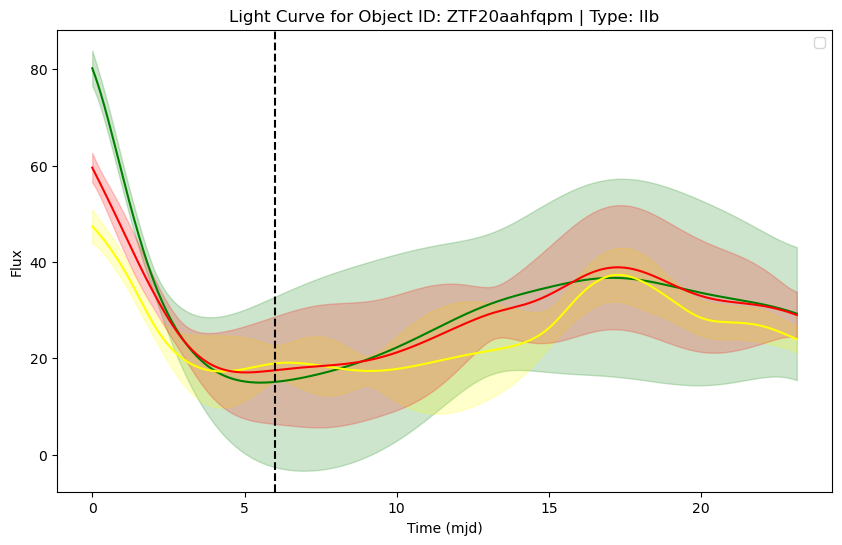

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


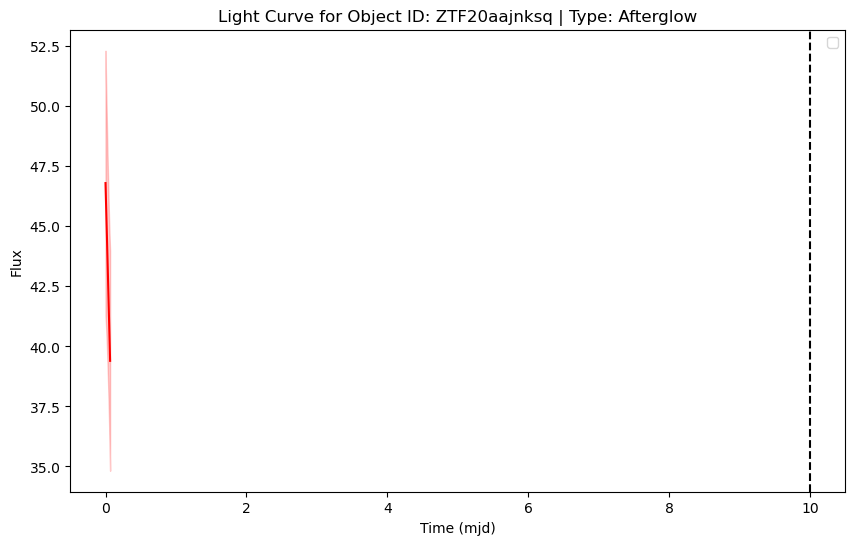

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


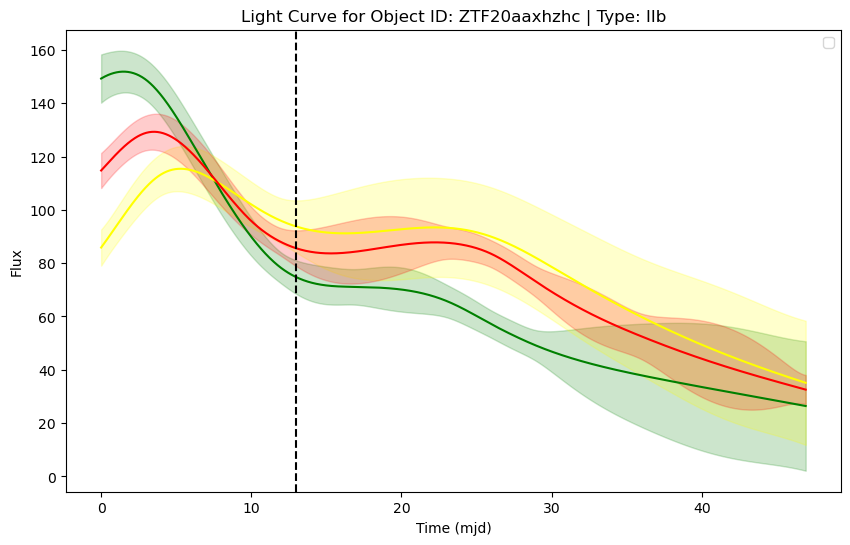

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


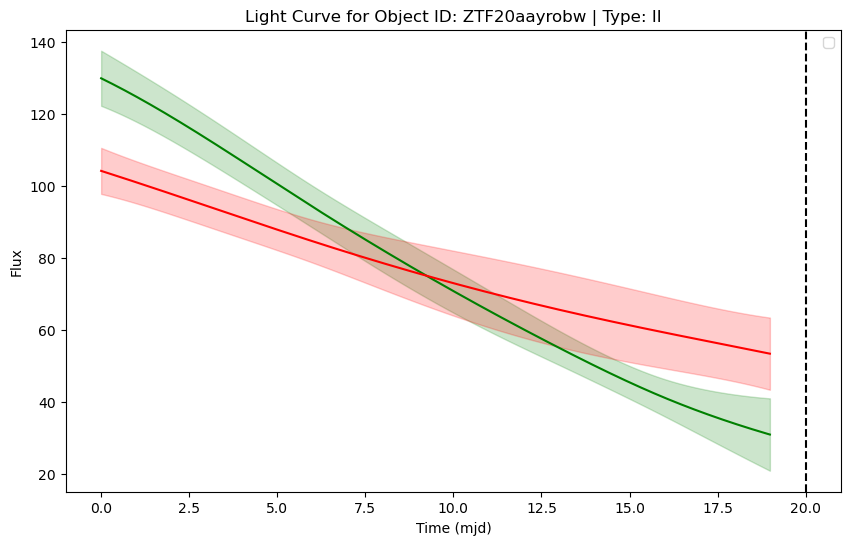

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


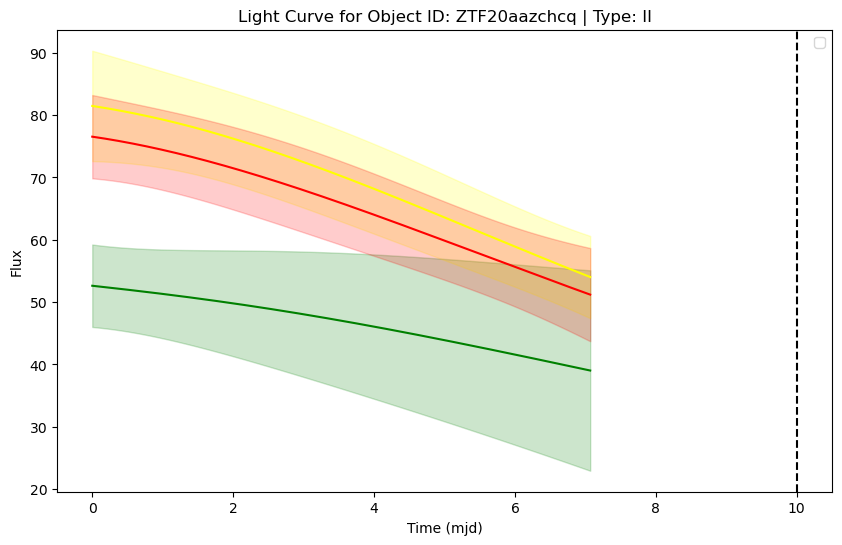

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


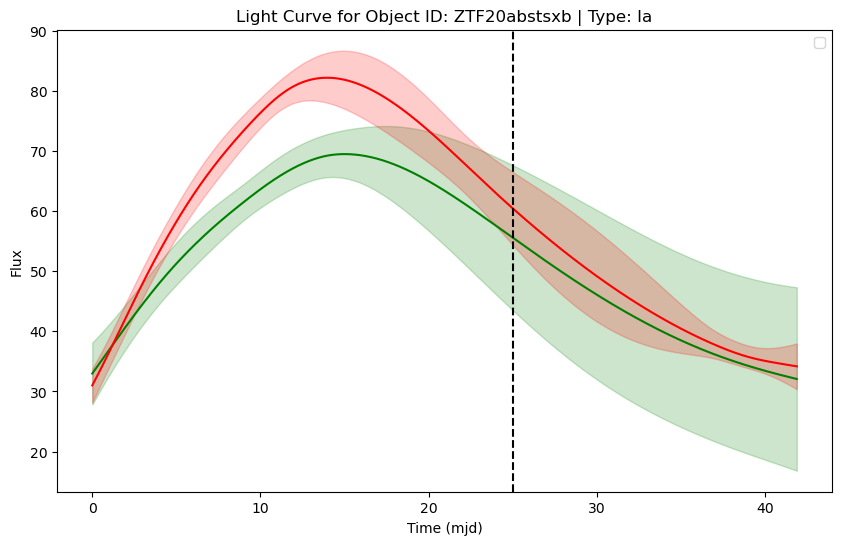

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


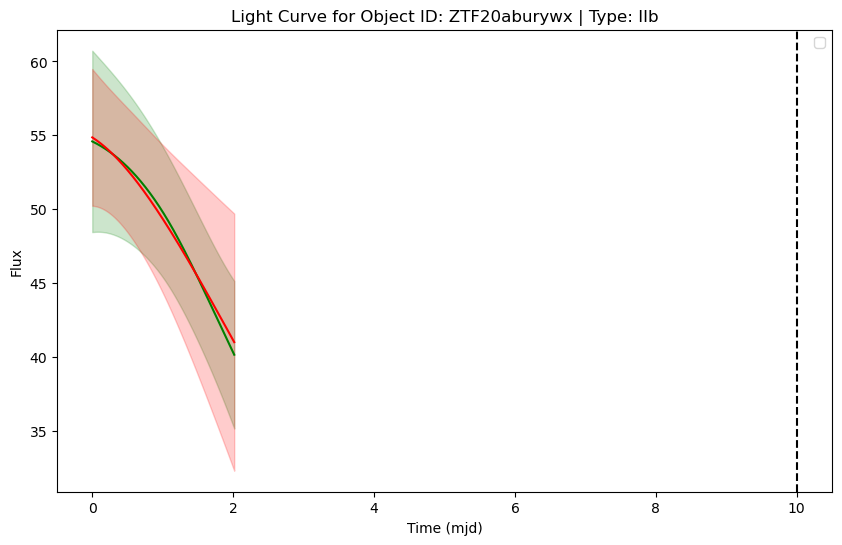

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


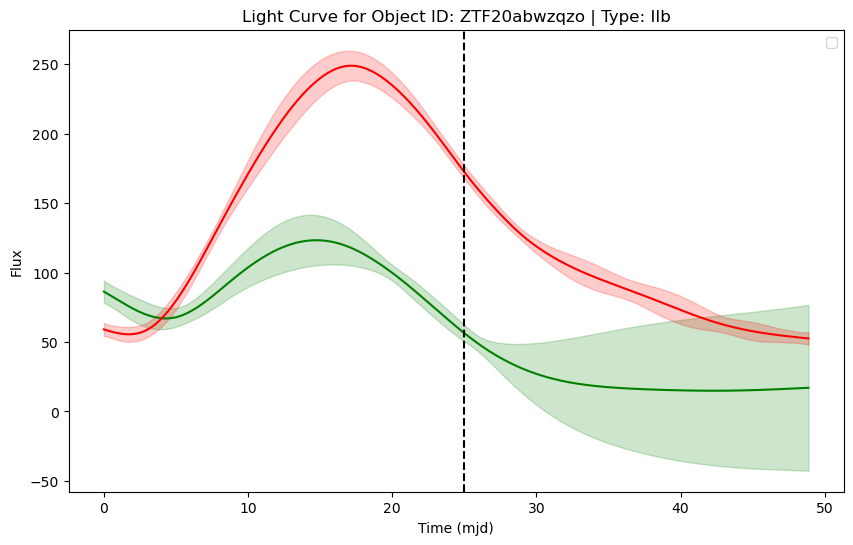

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


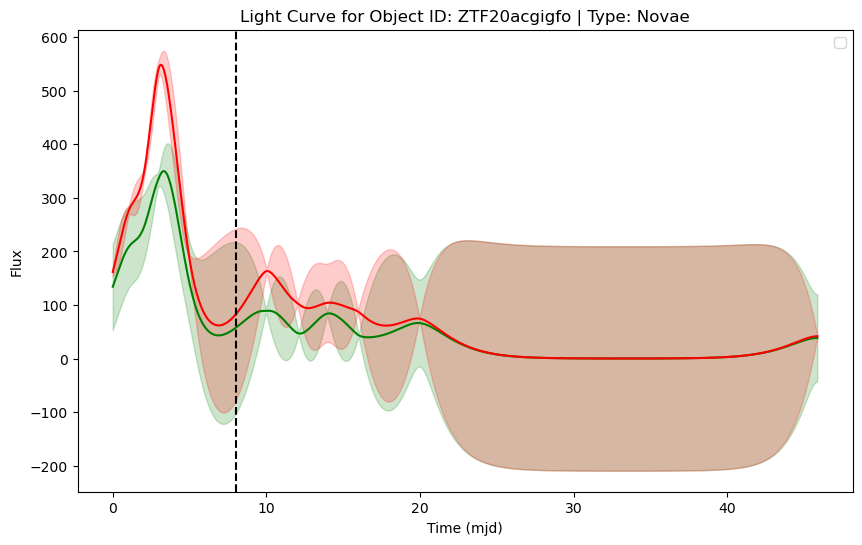

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


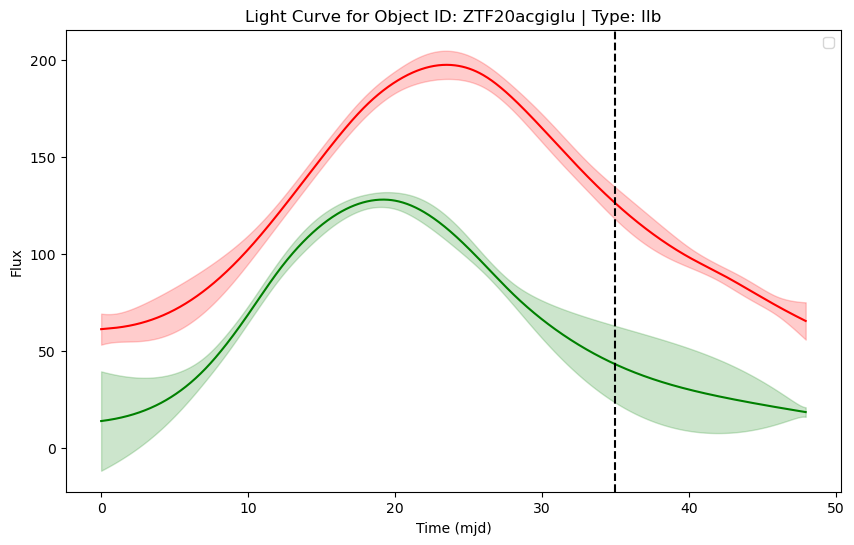

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


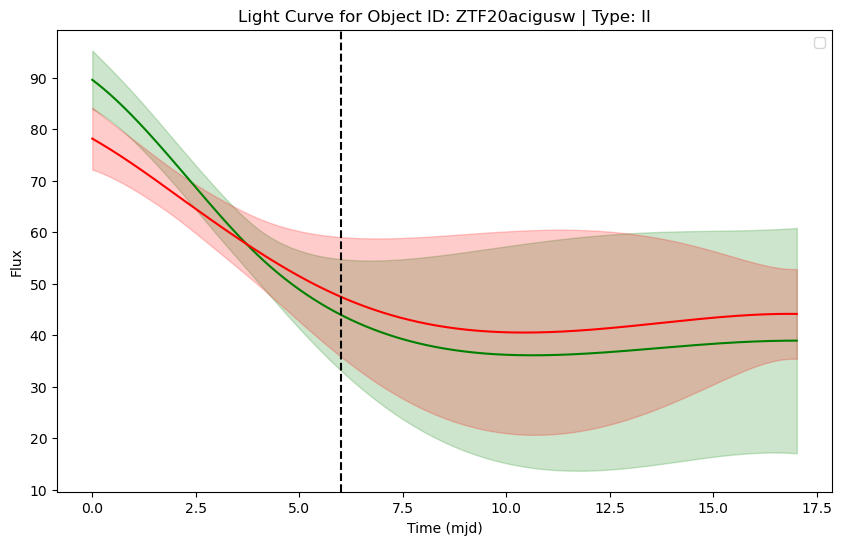

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


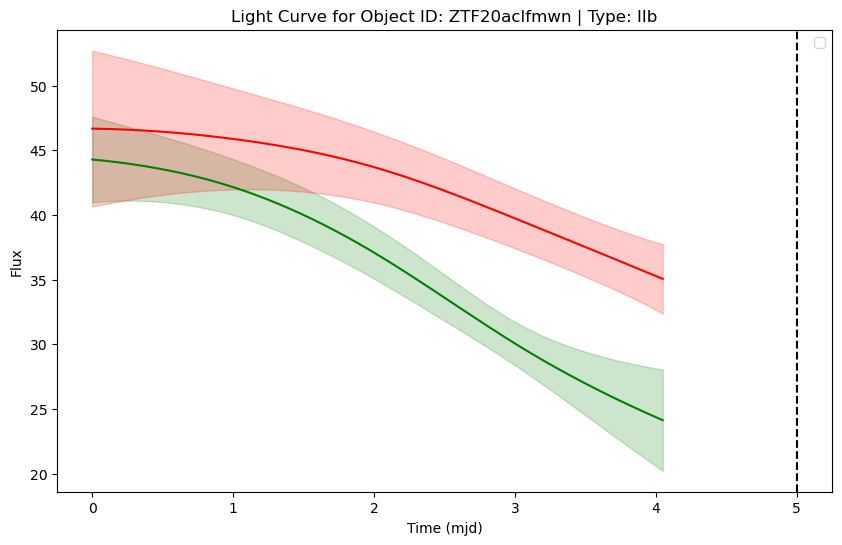

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


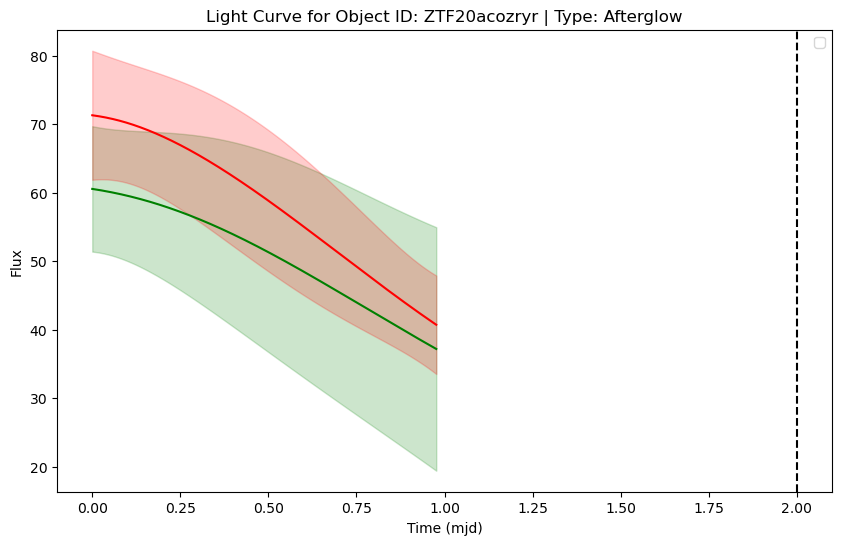

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


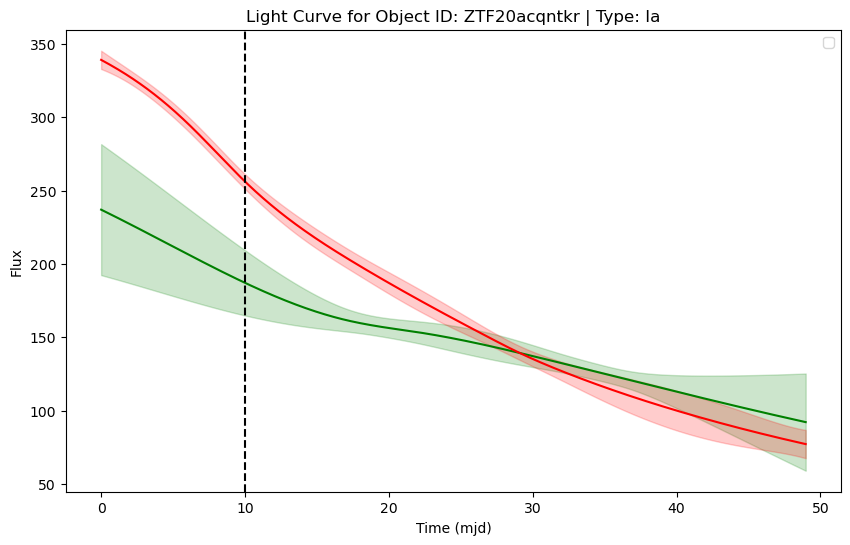

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


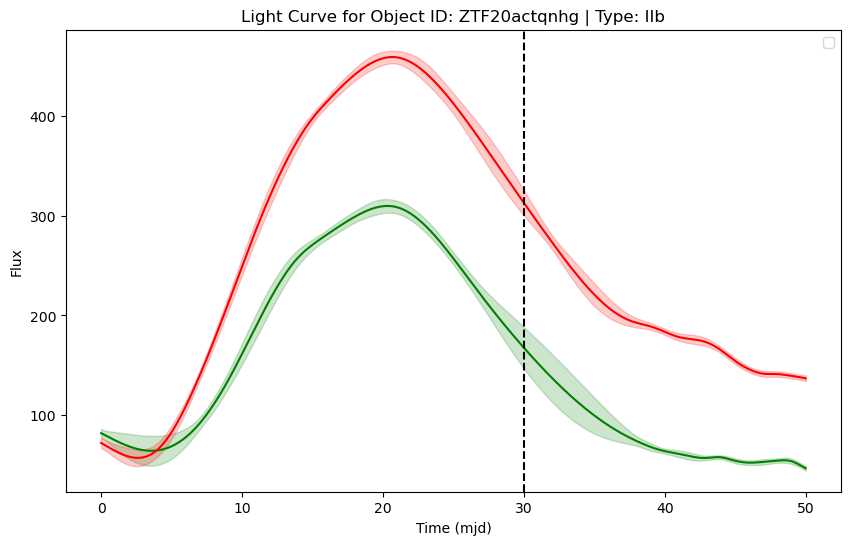

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


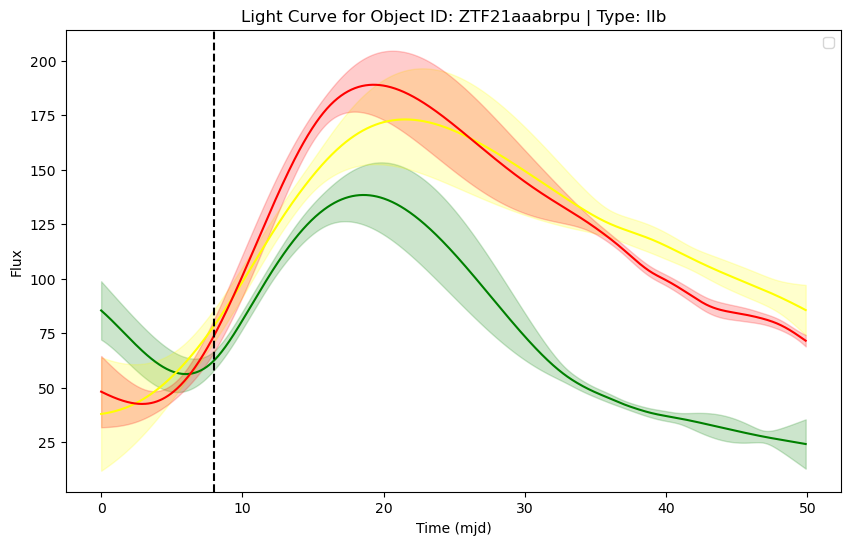

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


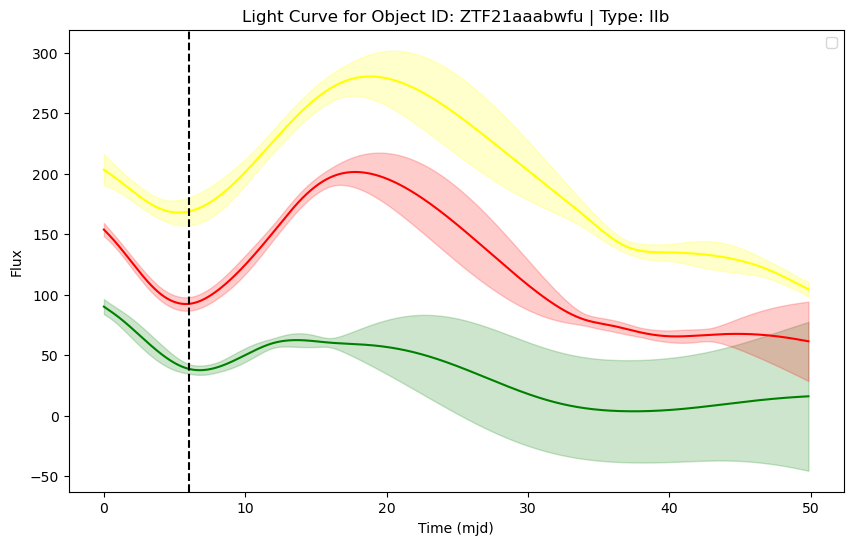

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


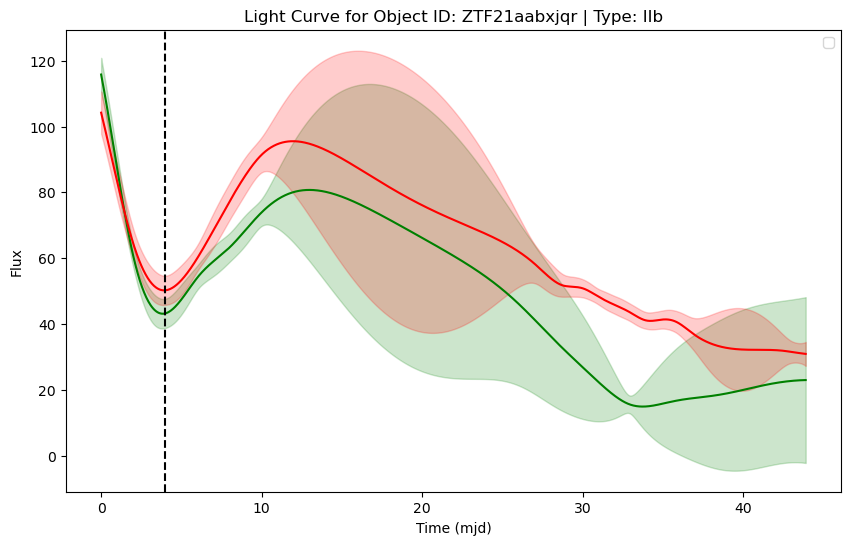

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


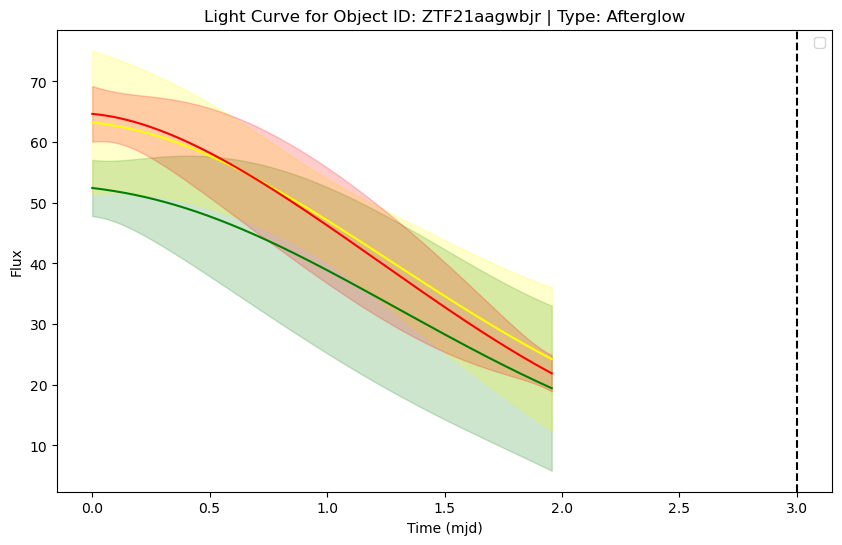

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


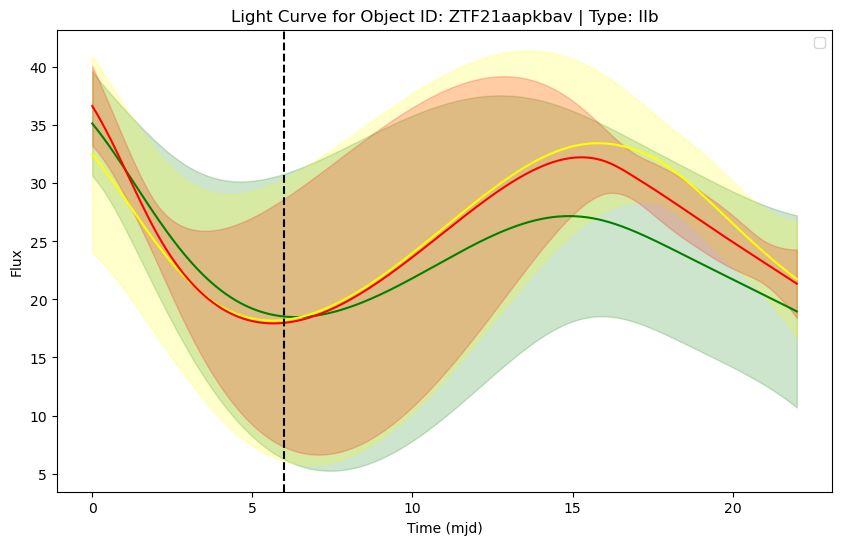

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


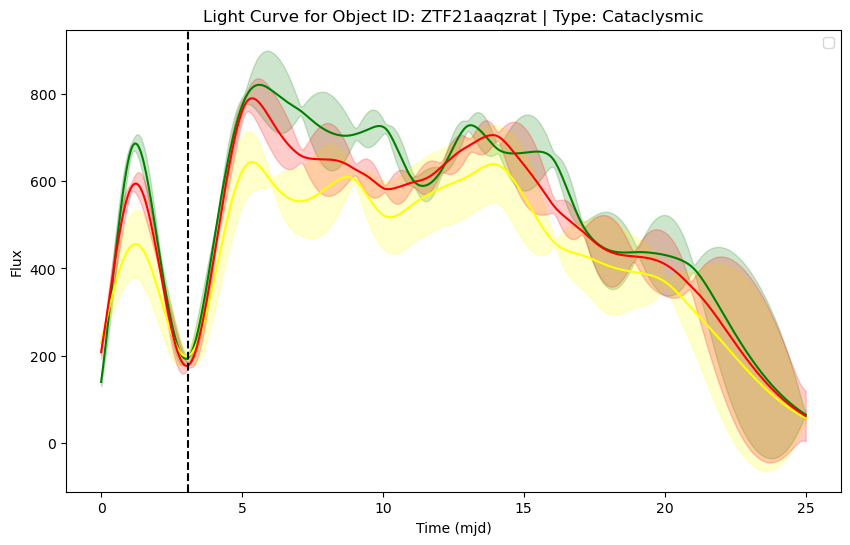

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


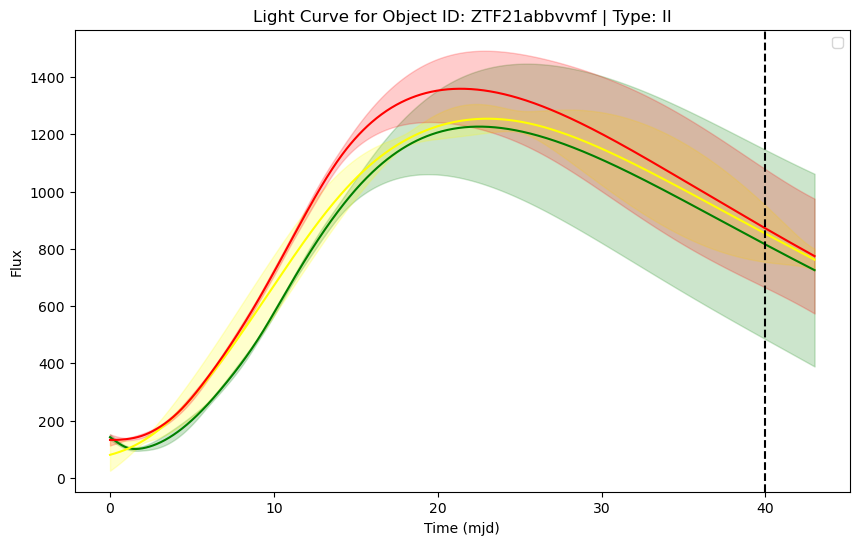

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


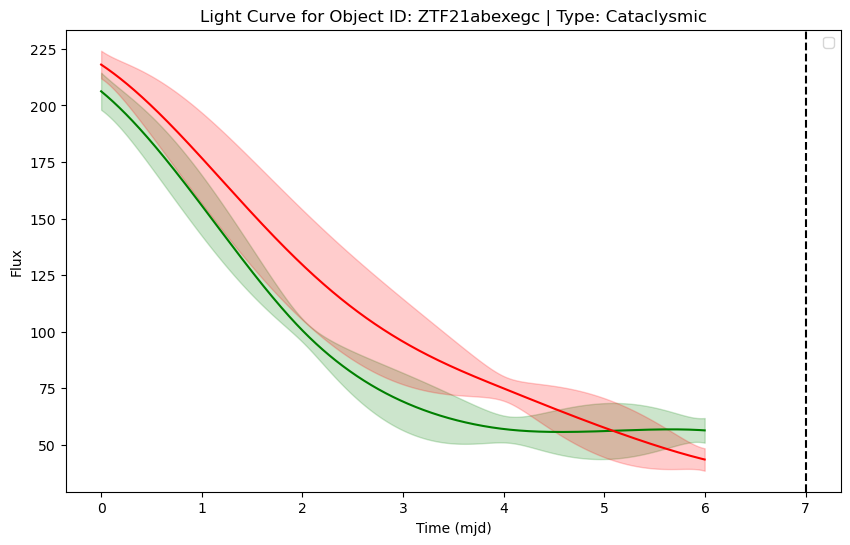

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


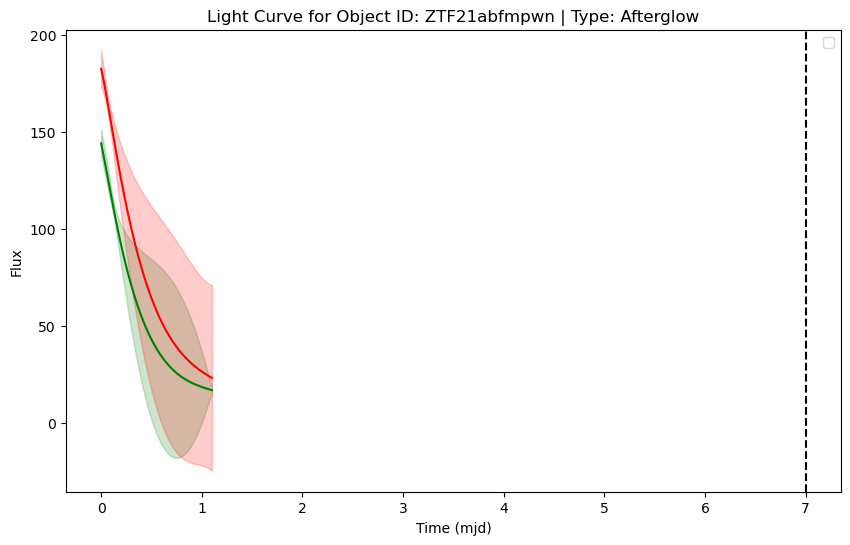

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


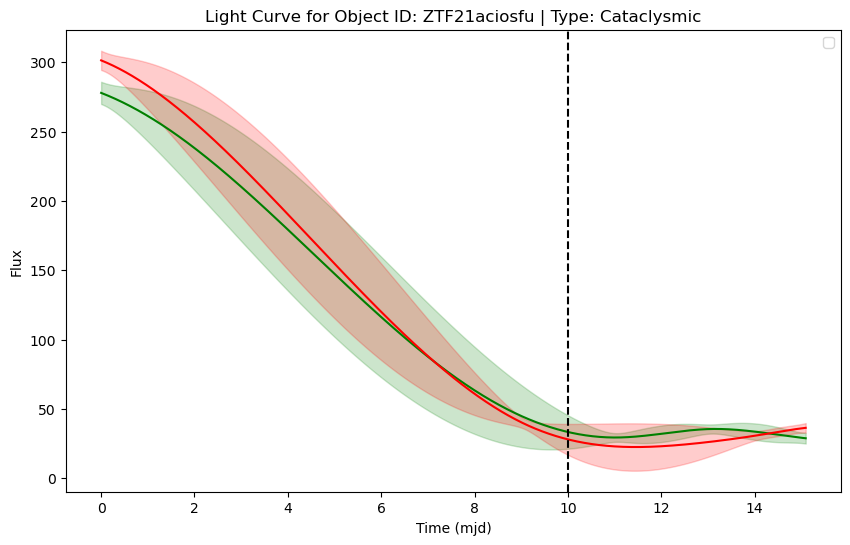

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


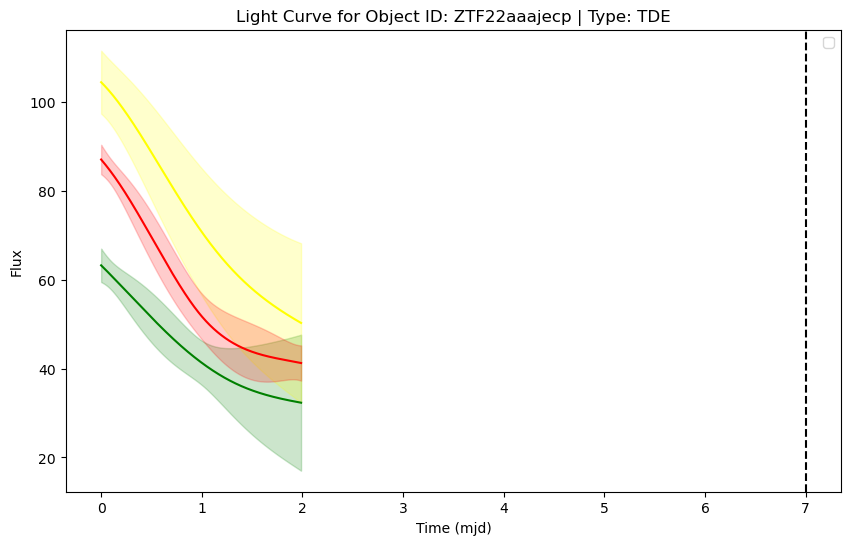

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


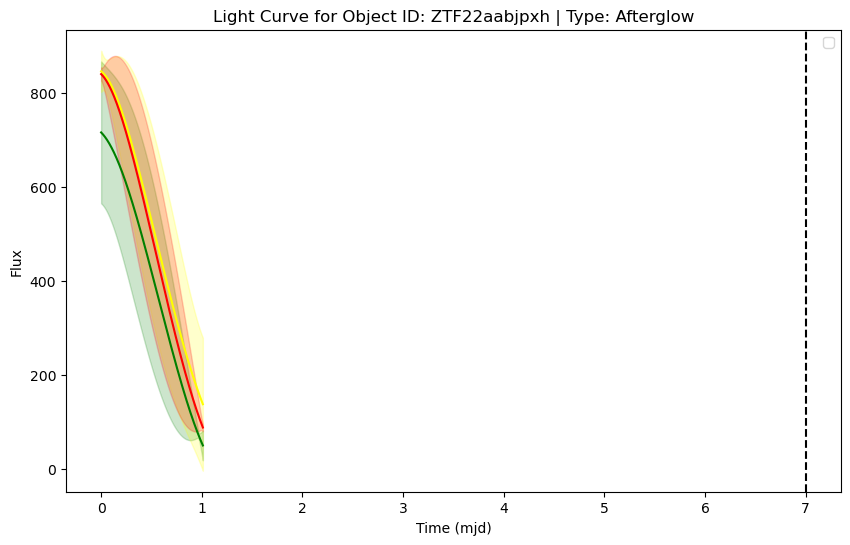

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


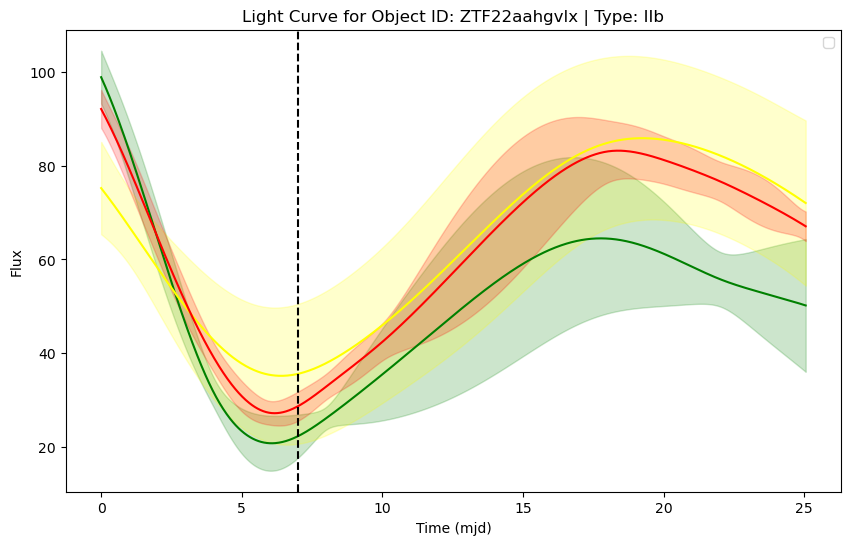

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


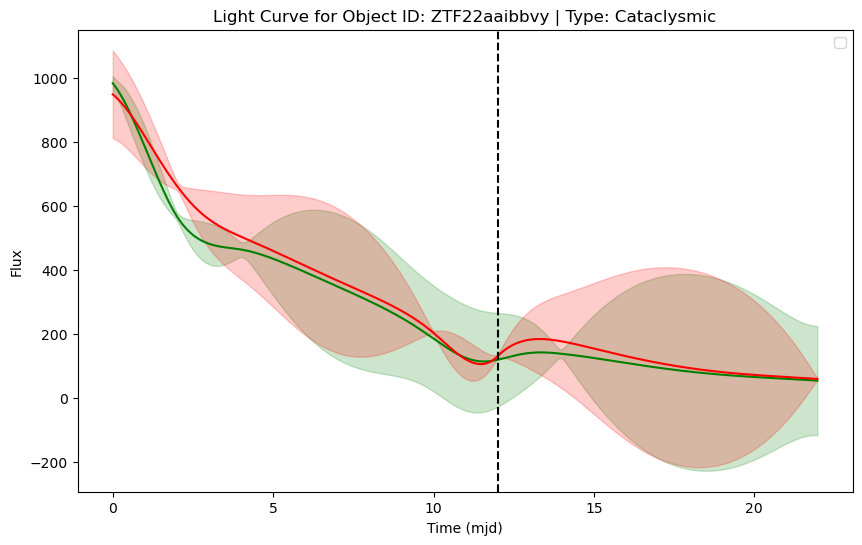

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


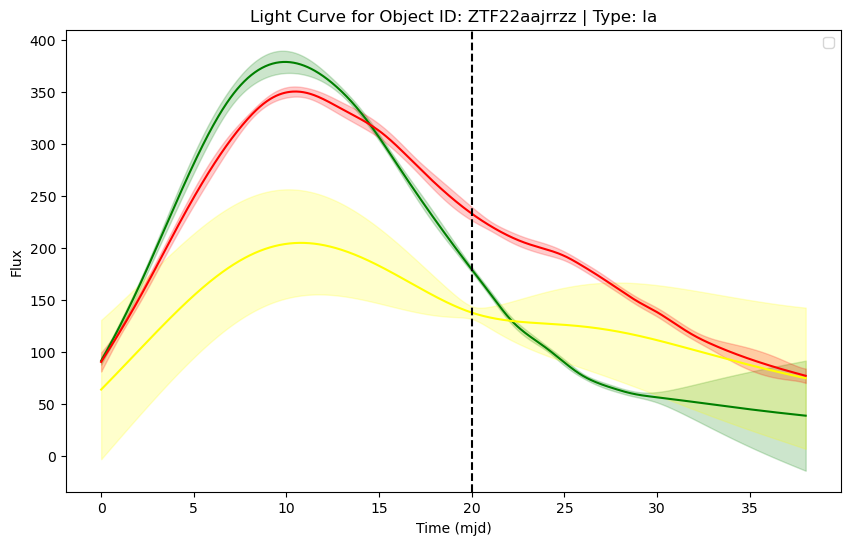

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


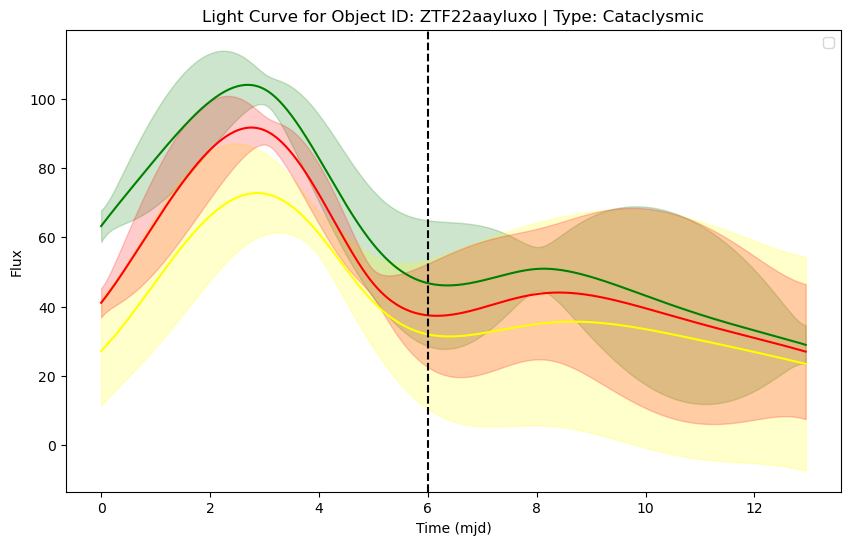

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


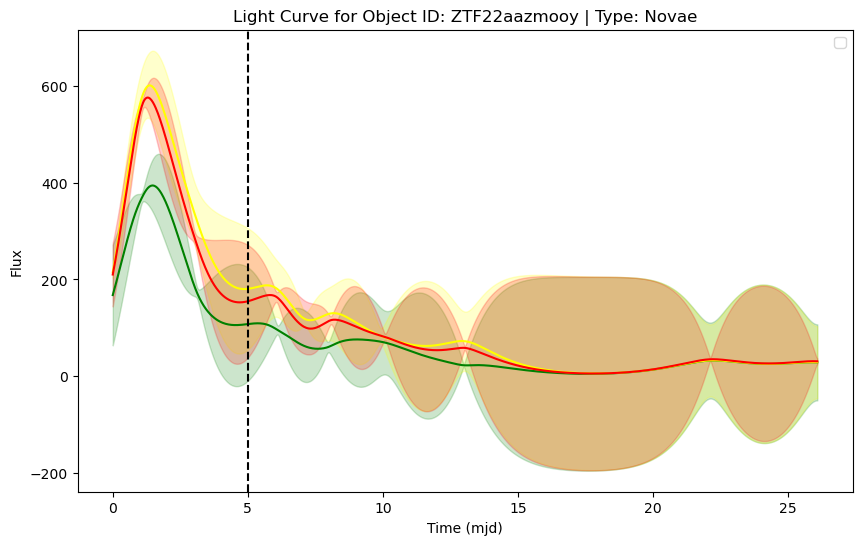

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


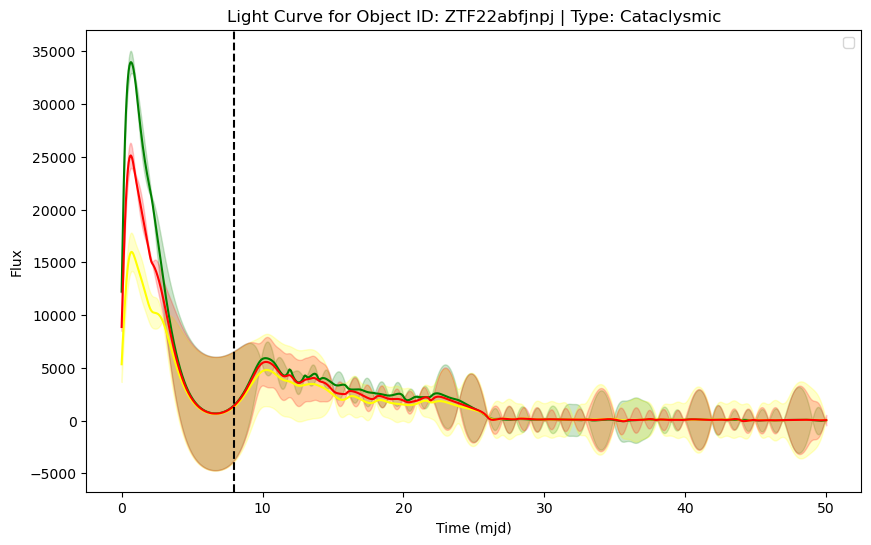

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


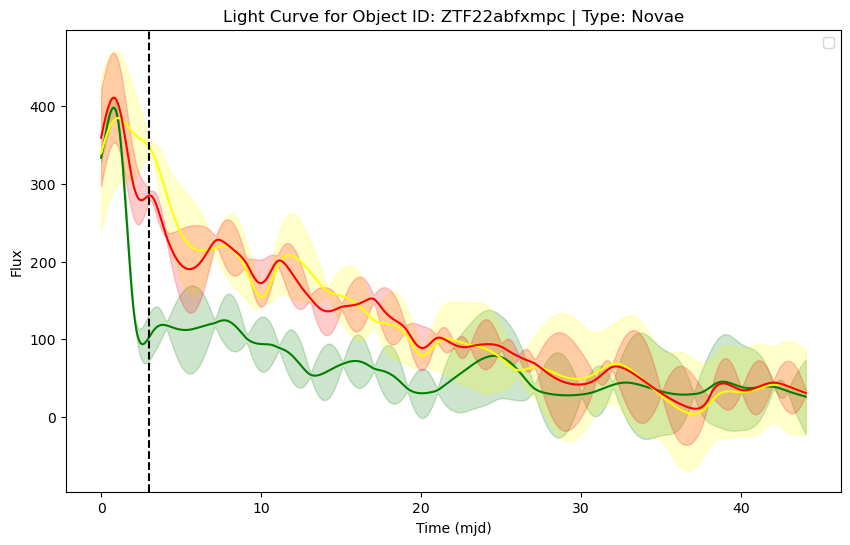

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


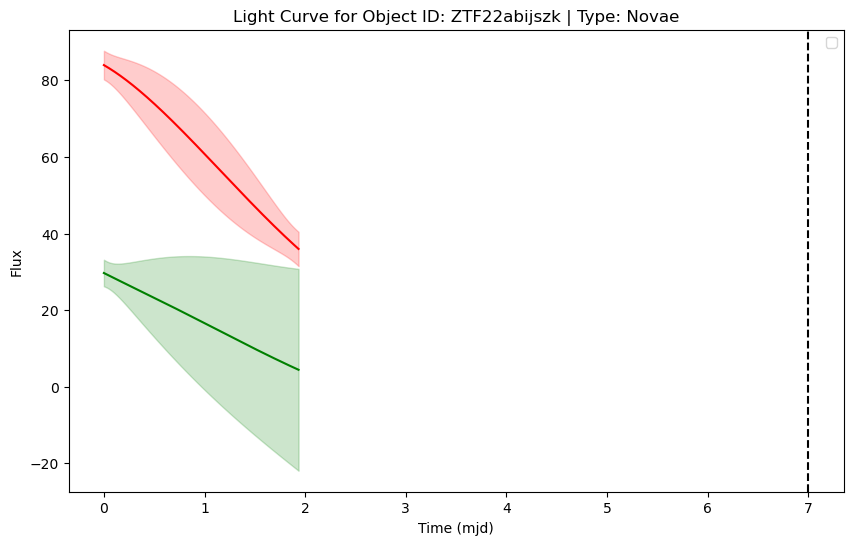

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


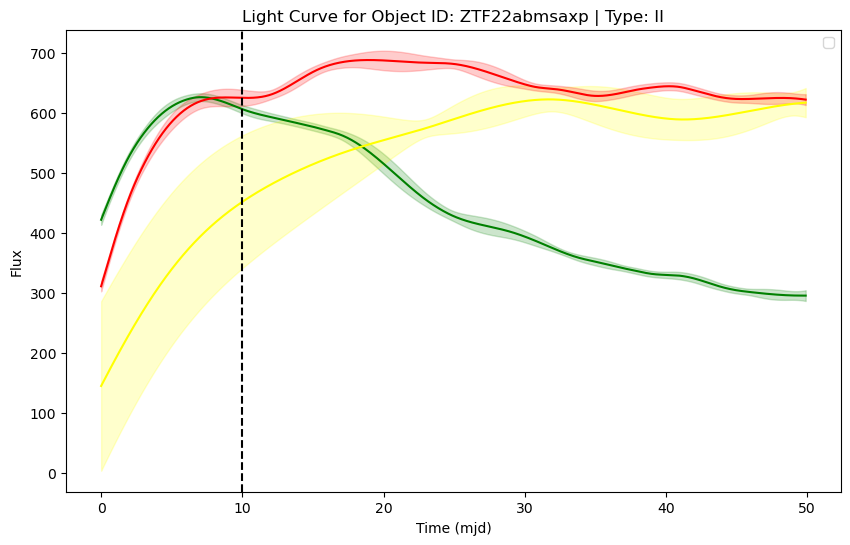

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


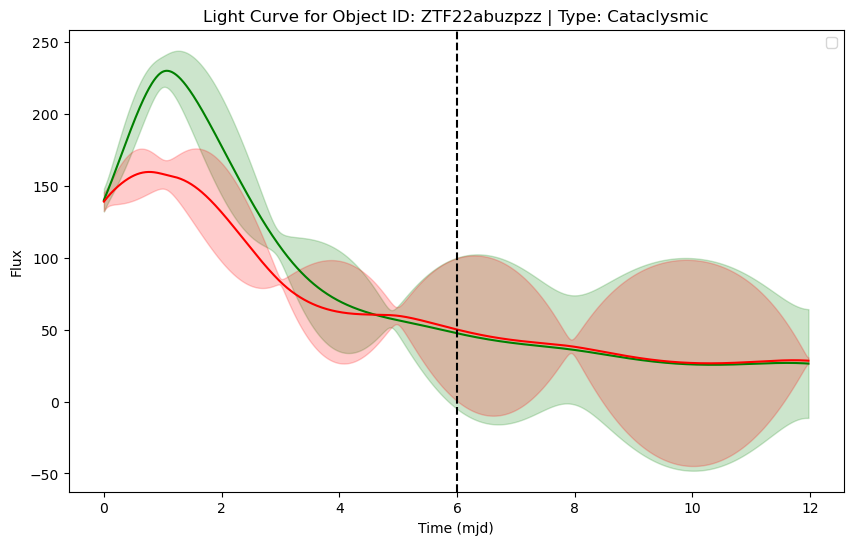

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


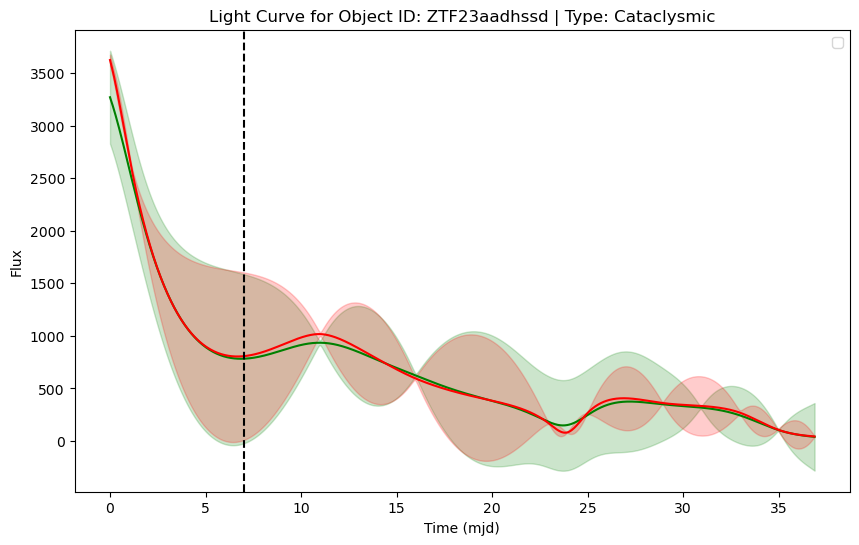

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


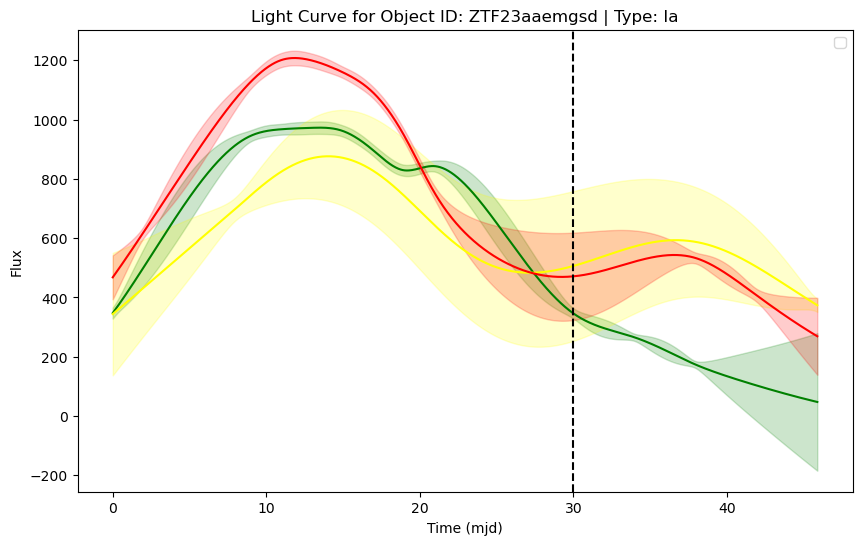

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


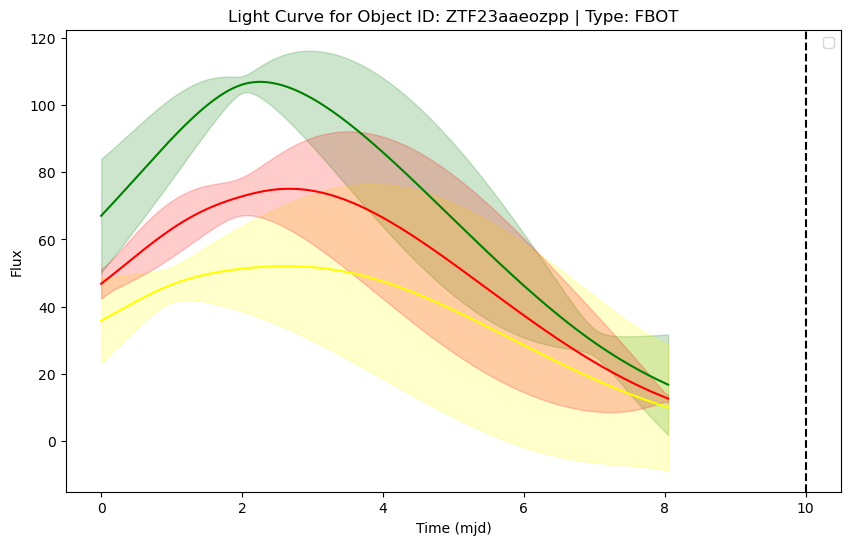

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


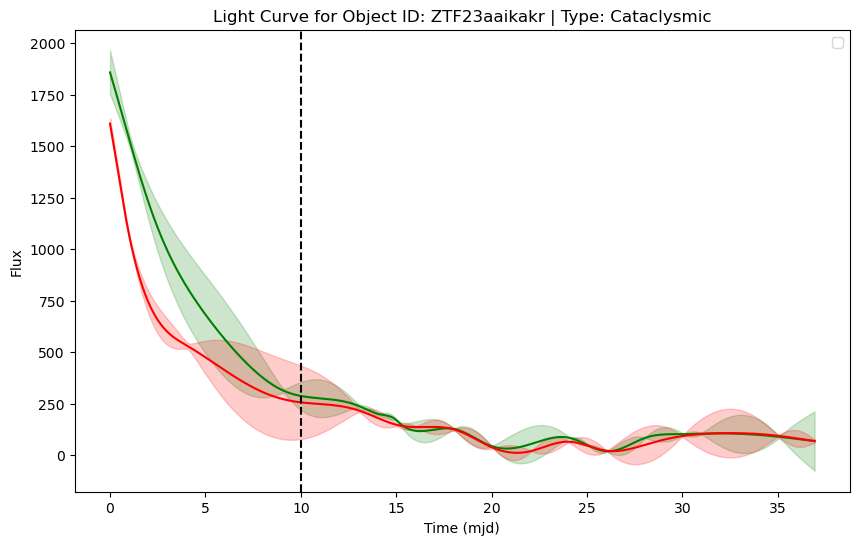

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


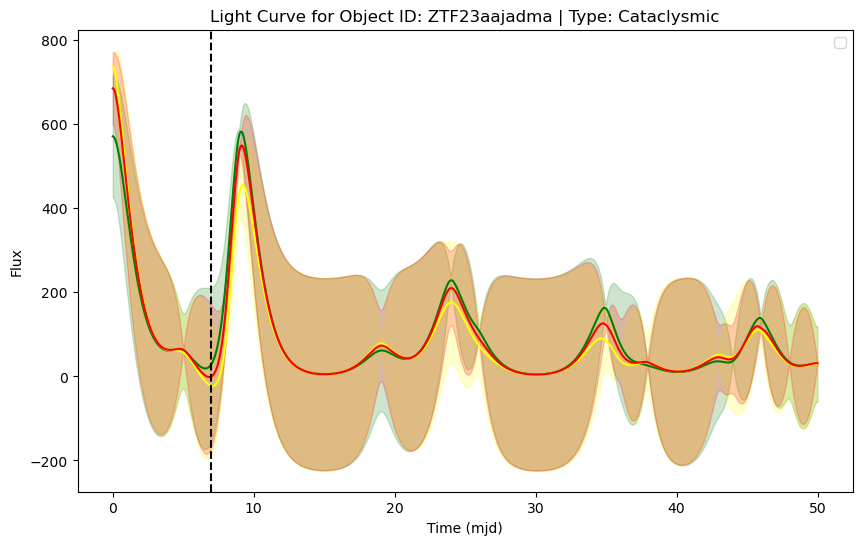

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


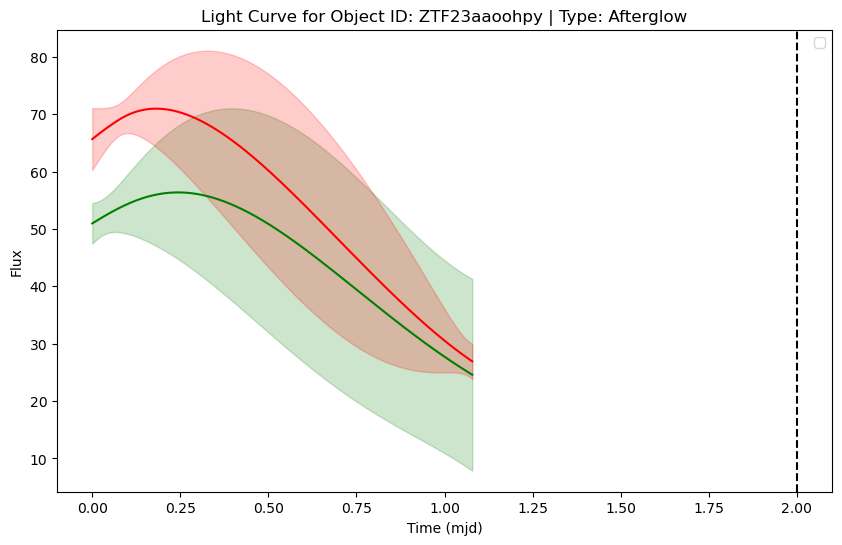

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


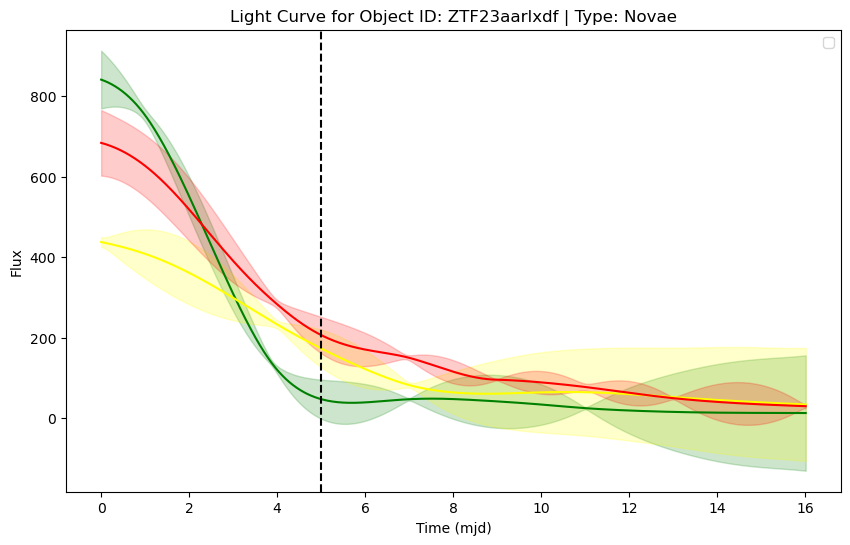

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


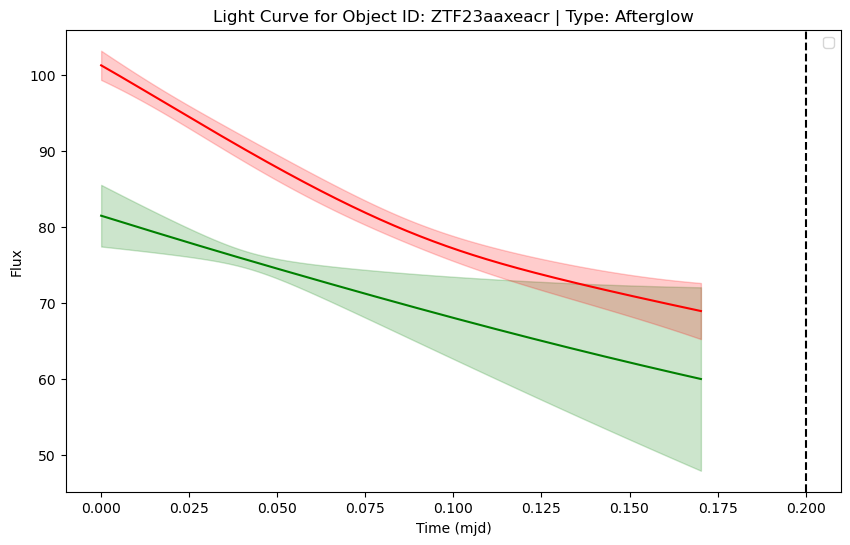

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


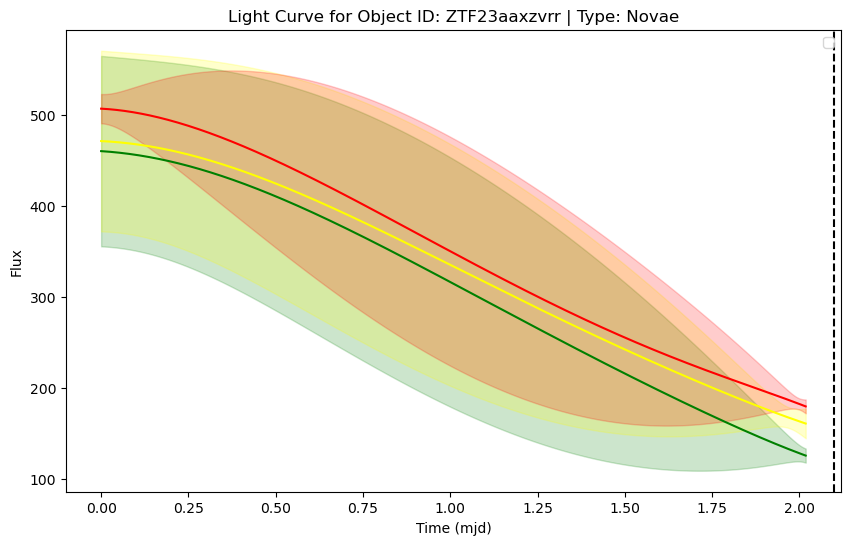

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


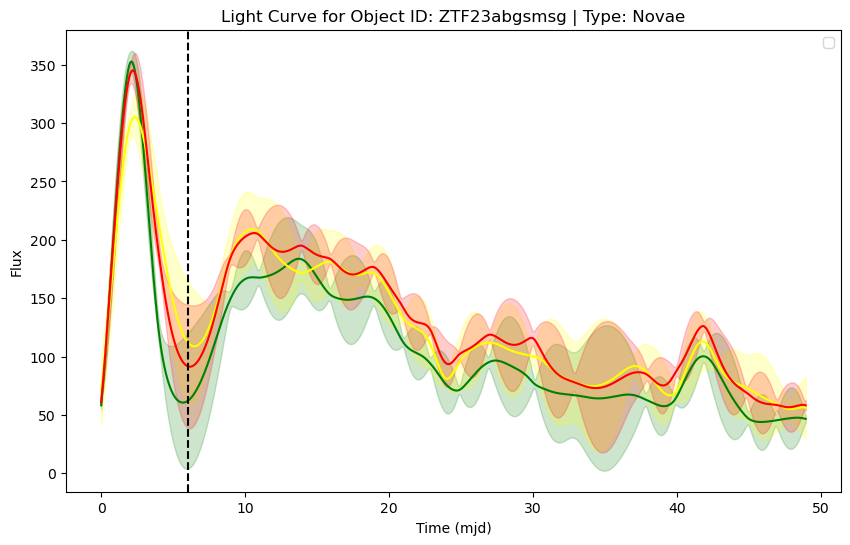

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


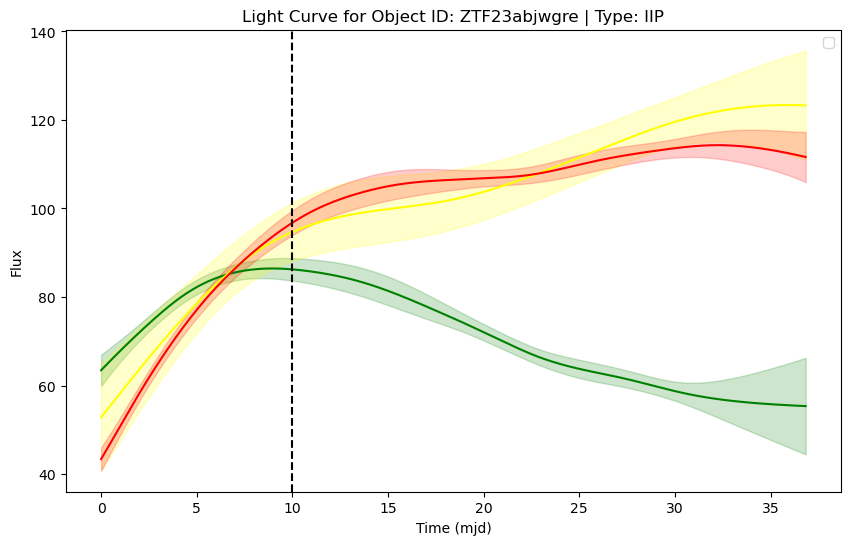

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


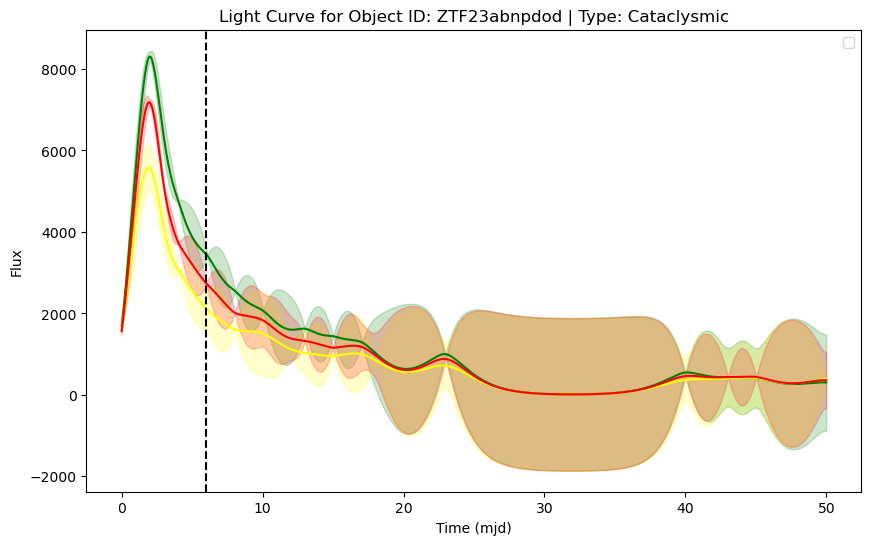

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


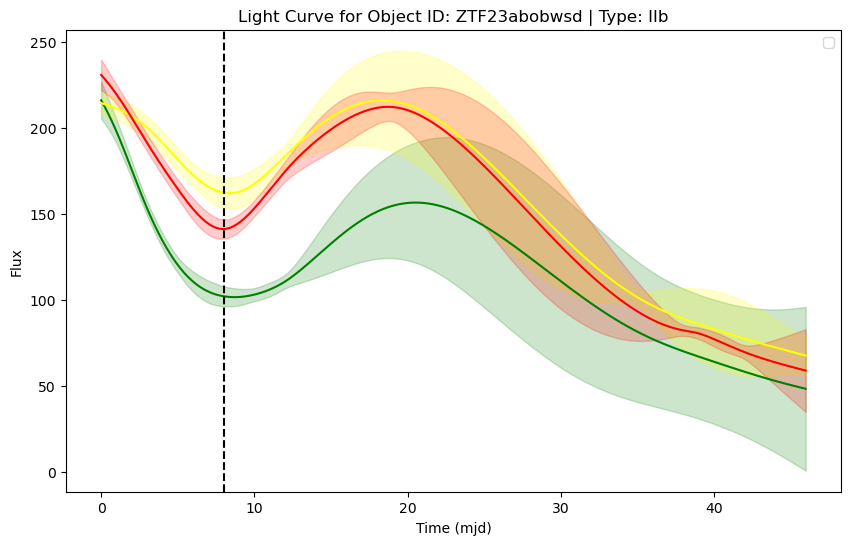

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


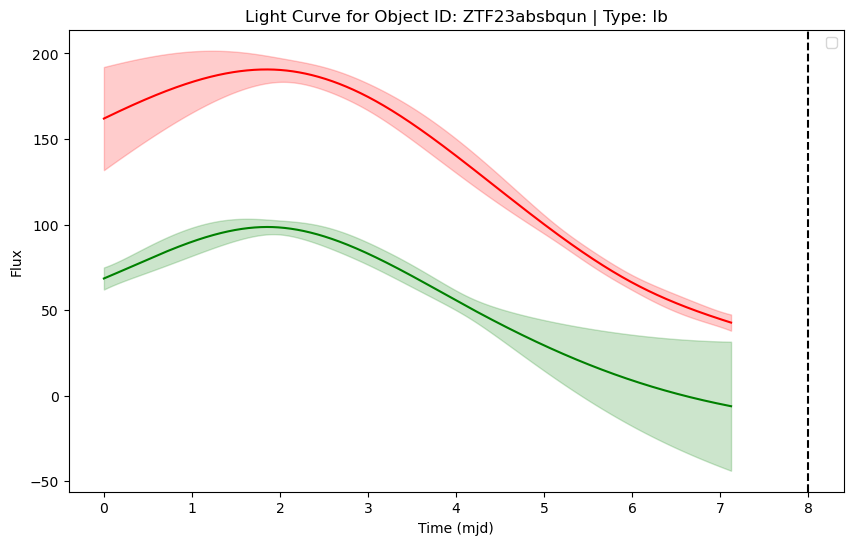

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


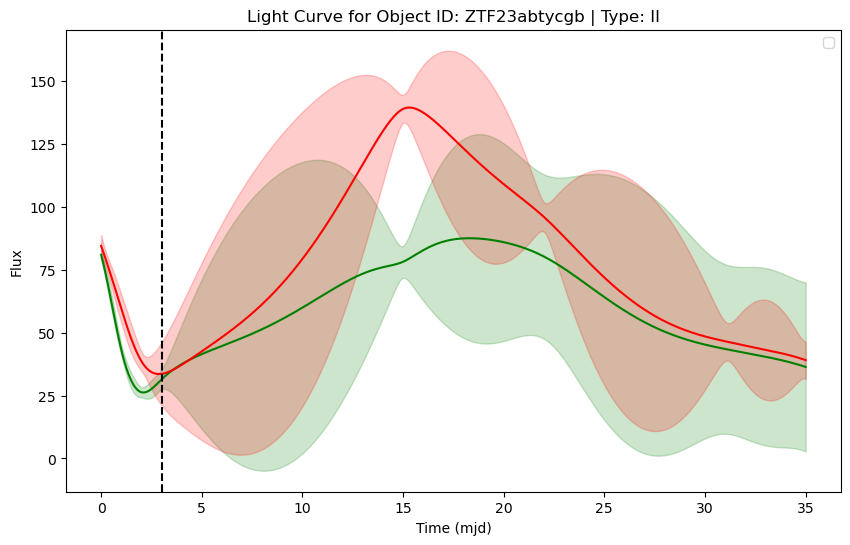

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


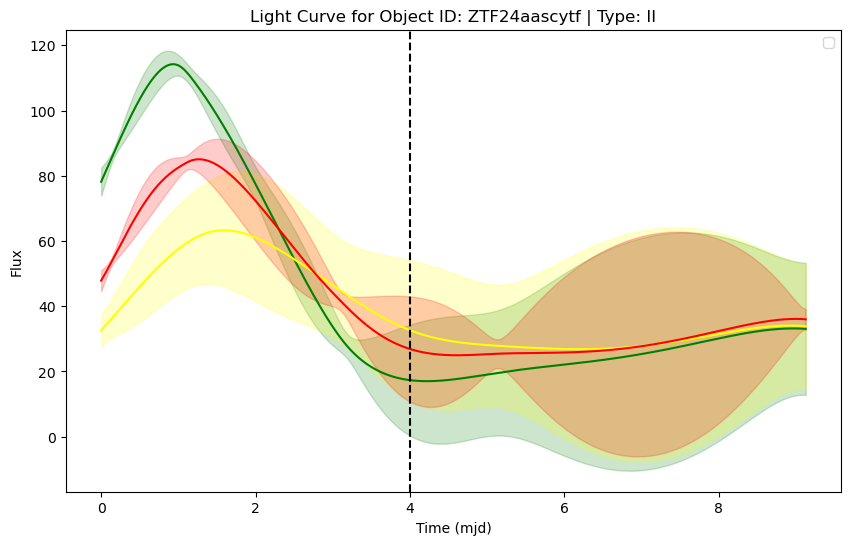

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


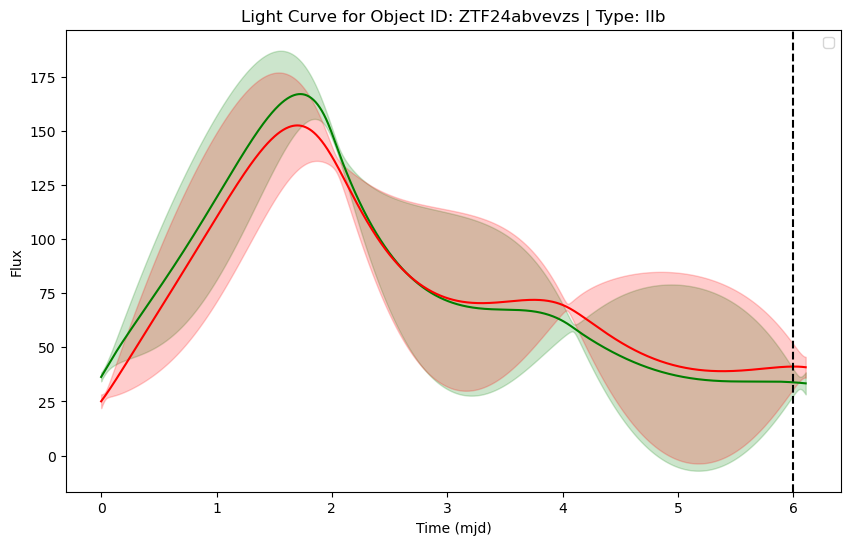

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


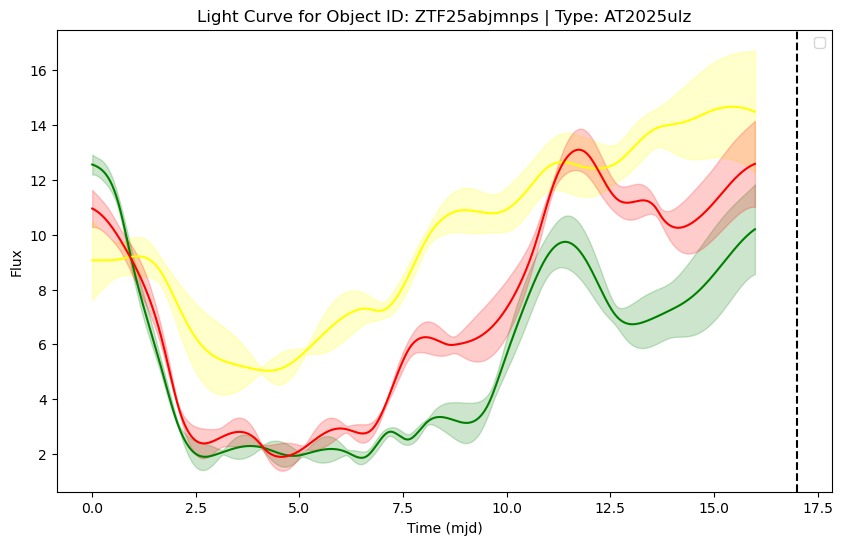

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


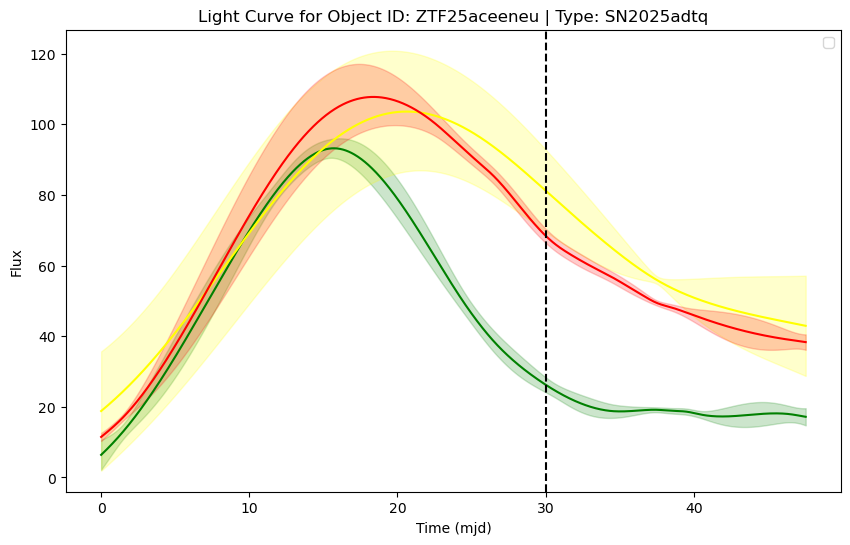

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


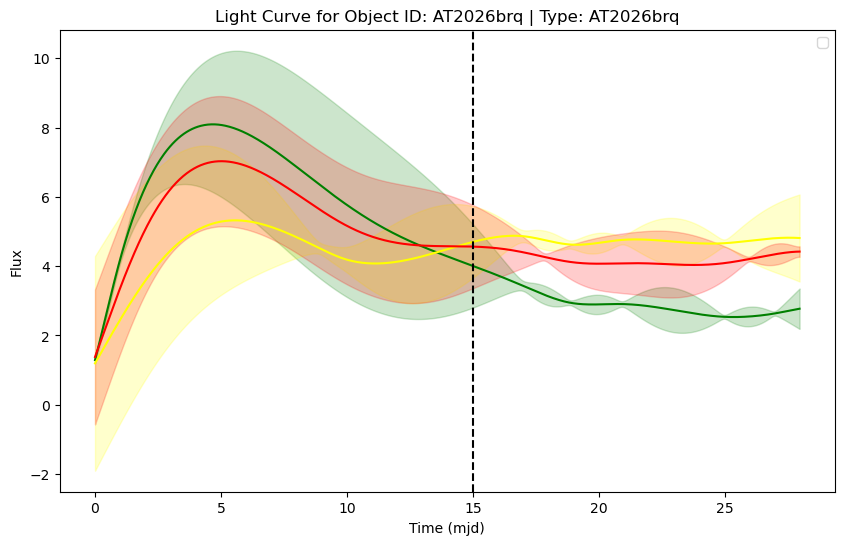

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


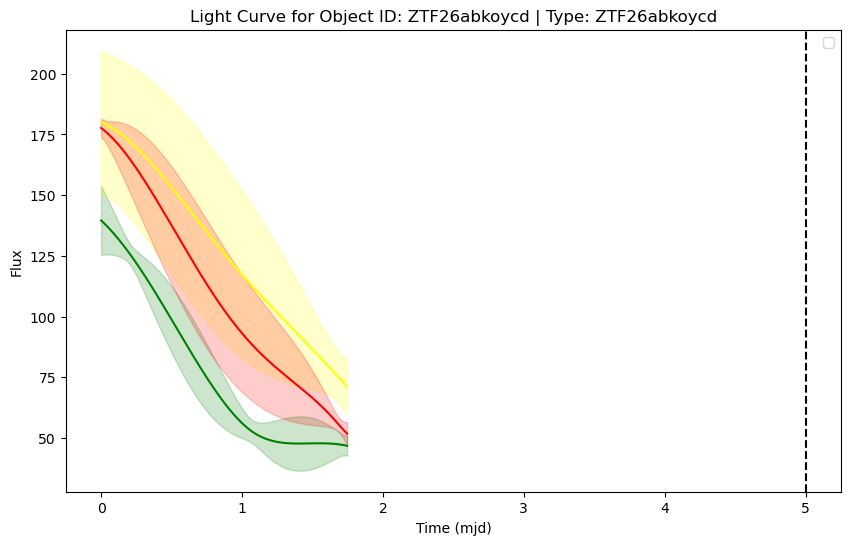

In [5]:
# Rules keyed by object name: numeric => cutoff time, NaN/'drop' => remove object entirely
cut_drop_rules = {
    'AT2017gfo': 10,
    'ZTF18aakuewf': 15,
    'ZTF18aalrxas': 7,
    'ZTF18abffyqp': 10,
    'ZTF18abvkmgw': 12,
    'ZTF18abwkrbl': 12,
    'ZTF19aanbpus': 23,
    'ZTF19aapfmki': 15,
    'ZTF19aatesgp': 12,
    'ZTF19abacxod': 6,
    'ZTF19abxjrge': 3,
    'ZTF19abxtcio': 25,
    'ZTF19abyjzvd': 11,
    'ZTF19acbumks': 10,
    'ZTF19accjfgv': 20,
    'ZTF20aahfqpm': 6,
    'ZTF20aajnksq': 10,
    'ZTF20aaxhzhc': 13,
    'ZTF20aayrobw': 20,
    'ZTF20aazchcq': 10,
    'ZTF20abstsxb': 25,
    'ZTF20aburywx': 10,
    'ZTF20abwysqy': 'drop',
    'ZTF20abwzqzo': 25,
    'ZTF20acgigfo': 8,
    'ZTF20acgiglu': 35,
    'ZTF20acigusw': 6,
    'ZTF20aclfmwn': 5,
    'ZTF20acozryr': 2,
    'ZTF20acqntkr': 10,
    'ZTF20actqnhg': 30,
    'ZTF21aaabrpu': 8,
    'ZTF21aaabwfu': 6,
    'ZTF21aabxjqr': 4,
    'ZTF21aagwbjr': 3,
    'ZTF21aapkbav': 6,
    'ZTF21aaqzrat': 3.1,
    'ZTF21abbvvmf': 40,
    'ZTF21abexegc': 7,
    'ZTF21abfmpwn': 7,
    'ZTF21abhywxv': 'drop',
    'ZTF21aciosfu': 10,
    'ZTF22aaajecp': 7,
    'ZTF22aabjpxh': 7,
    'ZTF22aahgvlx': 7,
    'ZTF22aaibbvy': 12,
    'ZTF22aajrrzz': 20,
    'ZTF22aayluxo': 6,
    'ZTF22aazmooy': 5,
    'ZTF22abfjnpj': 8,
    'ZTF22abfxmpc': 3,
    'ZTF22abijszk': 7,
    'ZTF22abmsaxp': 10,
    'ZTF22abuzpzz': 6,
    'ZTF22acaruqr': 'drop',
    'ZTF23aadhssd': 7,
    'ZTF23aaemgsd': 30,
    'ZTF23aaeozpp': 10,
    'ZTF23aaikakr': 10,
    'ZTF23aaimsja': 'drop',
    'ZTF23aajadma': 7,
    'ZTF23aaoohpy': 2,
    'ZTF23aarlxdf': 5,
    'ZTF23aaxeacr': 0.2,
    'ZTF23aaxzvrr': 2.1,
    'ZTF23abgsmsg': 6,
    'ZTF23abjwgre': 10,
    'ZTF23abnpdod': 6,
    'ZTF23abobwsd': 8,
    'ZTF23absafzo': 'drop',
    'ZTF23absbqun': 8,
    'ZTF23abtycgb': 3,
    'ZTF24aascytf': 4,
    'ZTF24abvevzs': 6,
    'ZTF25abjmnps': 17,
    'ZTF25aceeneu': 30,
    'AT2026brq': 15,
    'ZTF26abkoycd': 5,
    
}

available_ids = set(df['obj_id'].unique())
missing_rules = [obj_id for obj_id in cut_drop_rules if obj_id not in available_ids]
if missing_rules:
    print(f"Skipping {len(missing_rules)} rule(s) not present in df: {missing_rules}")

for obj_id, action in cut_drop_rules.items():
    if obj_id not in available_ids:
        continue

    if (isinstance(action, str) and action.lower() == 'drop') or pd.isna(action):
        df = df[df['obj_id'] != obj_id]
    else:
        df = cut_data(df, obj_id, float(action))

In [6]:
df[df['obj_id'] == obj[-1]]

,mjd,flux_ztfg,flux_ztfi,flux_ztfr,flux_error_ztfg,flux_error_ztfi,flux_error_ztfr,type,obj_id,mjd_0,...,mag_error_ztfg,mag_ztfr,abs_mag_ztfr,mag_error_ztfr,mag_ztfi,abs_mag_ztfi,mag_error_ztfi,t,rise,fade
76001,61250.242349,139.587586,180.052481,177.643626,14.125485,29.442350,3.934109,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.109870,18.276126,-25.288034,0.024045,18.261502,-25.302658,0.177541,0.000000,n,y
76002,61250.244097,139.492955,180.007268,177.568965,14.021351,29.440766,3.932500,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.109134,18.276582,-25.287577,0.024045,18.261775,-25.302385,0.177576,0.001747,n,y
76003,61250.245844,139.397884,179.961631,177.493586,13.917229,29.439555,3.935453,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.108398,18.277043,-25.287116,0.024073,18.262050,-25.302110,0.177613,0.003495,n,y
76004,61250.247592,139.302373,179.915570,177.417493,13.813120,29.438715,3.942921,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.107661,18.277509,-25.286651,0.024129,18.262328,-25.301832,0.177654,0.005242,n,y
76005,61250.249339,139.206422,179.869085,177.340688,13.709026,29.438246,3.954844,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.106923,18.277979,-25.286181,0.024213,18.262609,-25.301551,0.177697,0.006990,n,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76996,61251.981035,46.827461,71.513942,52.138438,4.065787,11.213241,4.392118,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094269,19.607105,-23.957055,0.091462,19.264023,-24.300137,0.170241,1.738686,n,y
76997,61251.982783,46.805967,71.402238,52.036069,4.063701,11.257768,4.477385,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094264,19.609239,-23.954921,0.093421,19.265720,-24.298439,0.171185,1.740433,n,y
76998,61251.984530,46.784158,71.290549,51.934233,4.064583,11.303560,4.563905,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094328,19.611366,-23.952794,0.095413,19.267420,-24.296740,0.172150,1.742181,n,y
76999,61251.986278,46.762033,71.178879,51.832925,4.068474,11.350597,4.651602,ZTF26abkoycd,ZTF26abkoycd,61250.242349,...,0.094463,19.613486,-23.950674,0.097436,19.269122,-24.295038,0.173138,1.743928,n,y


In [7]:
# df = pd.read_csv('gp/gp_objects_gp1000.csv')
rise_fade = pd.read_csv('gp/gp_rise_fade_stats.csv')
rise_fade

,Object,rise,fade,notes
0,ZTF18aakuewf,y,y,NaN
1,ZTF18aalrxas,y,y,NaN
2,ZTF18abffyqp,y,y,NaN
3,ZTF18abvkmgw,y,y,NaN
4,ZTF18abwkrbl,y,y,NaN
...,...,...,...,...
70,AT2017gfo,n,y,NaN
71,ZTF25abjmnps,n,y,cut at 2.1 with Wendelstein 3KK data
72,ZTF25aceeneu,y,y,NaN
73,AT2026brq,y,y,lsst object


In [8]:
rise_fade.columns

Index(['Object', 'rise', 'fade', 'notes'], dtype='object')

In [9]:
df[df['obj_id'] == obj[-10]]

,mjd,flux_ztfg,flux_ztfi,flux_ztfr,flux_error_ztfg,flux_error_ztfi,flux_error_ztfr,type,obj_id,mjd_0,...,mag_error_ztfg,mag_ztfr,abs_mag_ztfr,mag_error_ztfr,mag_ztfi,abs_mag_ztfi,mag_error_ztfi,t,rise,fade
67001,60245.132662,1693.831332,1611.524221,1564.928105,29.238978,178.900443,73.918773,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.018742,15.913764,1.350528,0.051284,15.881908,1.318672,0.120531,0.000000,y,y
67002,60245.182698,1841.077120,1724.099434,1699.897797,72.954449,116.764829,30.559905,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.043023,15.823943,1.260707,0.019519,15.808594,1.245359,0.073532,0.050036,y,y
67003,60245.232734,1996.087872,1840.108455,1842.234481,133.701065,58.482742,73.040770,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.072724,15.736638,1.173402,0.043047,15.737891,1.174656,0.034507,0.100072,y,y
67004,60245.282770,2158.451379,1959.214902,1991.496877,192.865377,44.678197,132.750946,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.097014,15.652051,1.088815,0.072374,15.669795,1.106559,0.024759,0.150108,y,y
67005,60245.332806,2327.733739,2081.160112,2147.110665,249.028655,96.496255,190.881677,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.116156,15.570364,1.007128,0.096524,15.604236,1.041001,0.050342,0.200144,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67116,60250.886802,3537.306655,2208.445430,2842.927033,377.640574,578.165020,302.953578,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.115912,15.265586,0.702350,0.115700,15.539783,0.976548,0.284243,5.754140,y,y
67117,60250.936838,3520.630218,2187.655189,2820.952054,331.899311,566.179251,253.967317,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.102355,15.274011,0.710775,0.097748,15.550053,0.986817,0.280996,5.804176,y,y
67118,60250.986874,3503.939805,2167.472309,2799.365258,283.349930,556.320652,202.350408,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.087799,15.282351,0.719116,0.078482,15.560116,0.996881,0.278674,5.854212,y,y
67119,60251.036910,3486.983918,2147.933913,2778.260101,232.207071,549.175200,148.838966,Cataclysmic,ZTF23abnpdod,60245.132662,...,0.072302,15.290568,0.727332,0.058166,15.569948,1.006712,0.277597,5.904248,y,y


In [10]:
df.type.unique()

array(['Kilonova', 'Ibn', 'IIb', 'II', 'Ib', 'Afterglow', 'Ia', 'Novae',
       'Cataclysmic', 'TDE', 'FBOT', 'IIP', 'AT2025ulz', 'SN2025adtq',
       'AT2026brq', 'ZTF26abkoycd'], dtype=object)

In [11]:
df.obj_id.unique()

array(['AT2017gfo', 'ZTF18aakuewf', 'ZTF18aalrxas', 'ZTF18abffyqp',
       'ZTF18abvkmgw', 'ZTF18abwkrbl', 'ZTF19aanbpus', 'ZTF19aapfmki',
       'ZTF19aatesgp', 'ZTF19abacxod', 'ZTF19abxjrge', 'ZTF19abxtcio',
       'ZTF19abyjzvd', 'ZTF19acbumks', 'ZTF19accjfgv', 'ZTF20aahfqpm',
       'ZTF20aajnksq', 'ZTF20aaxhzhc', 'ZTF20aayrobw', 'ZTF20aazchcq',
       'ZTF20abstsxb', 'ZTF20aburywx', 'ZTF20abwzqzo', 'ZTF20acgigfo',
       'ZTF20acgiglu', 'ZTF20acigusw', 'ZTF20aclfmwn', 'ZTF20acozryr',
       'ZTF20acqntkr', 'ZTF20actqnhg', 'ZTF21aaabrpu', 'ZTF21aaabwfu',
       'ZTF21aabxjqr', 'ZTF21aagwbjr', 'ZTF21aapkbav', 'ZTF21aaqzrat',
       'ZTF21abbvvmf', 'ZTF21abexegc', 'ZTF21abfmpwn', 'ZTF21aciosfu',
       'ZTF22aaajecp', 'ZTF22aabjpxh', 'ZTF22aahgvlx', 'ZTF22aaibbvy',
       'ZTF22aajrrzz', 'ZTF22aayluxo', 'ZTF22aazmooy', 'ZTF22abfjnpj',
       'ZTF22abfxmpc', 'ZTF22abijszk', 'ZTF22abmsaxp', 'ZTF22abuzpzz',
       'ZTF23aadhssd', 'ZTF23aaemgsd', 'ZTF23aaeozpp', 'ZTF23aaikakr',
       'Z

In [12]:
df.to_csv('gp/gp_objects(downsample).csv', index=False)